# 2×2 method-comparison plot template

Layout:
- (0, 0) Modular addition — clean expert (η = 0.0)
- (0, 1) Modular addition — noisy expert (η = 0.2)
- (1, 0) GSM — clean expert
- (1, 1) GSM — noisy expert

Each panel: x = training step, y = accuracy. Five methods per panel: **Offline BC, OPD-F, OPD-R, NAIL-F, NAIL-R**, each with shaded ±std confidence band aggregated across seeds.

Style mirrors the AdaBeMA paper template (serif font, grey grid, lw=7, dpi=300). Per-panel size: 16/3 × 4 → 2×2 grid is 32/3 × 8 (≈10.67 × 8 in).

In [63]:
import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.lines import Line2D
from matplotlib.ticker import MaxNLocator, FormatStrFormatter, FuncFormatter, FixedLocator
import numpy as np


TITLE_FONTSIZE = 22
LEGEND_FONTSIZE = 17
LABEL_FONTSIZE = 21
TICK_FONTSIZE = 17

# NAIL = blue family, OPD = red family. F = light shade, R = dark shade.
# ColorBrewer Blues-5 / Reds-5, positions 3 (light) and 5 (dark).
NAIL_F_COLOR = "#6baed6"   # light blue
NAIL_R_COLOR = "#08519c"   # dark blue
OPD_F_COLOR  = "#fb6a4a"   # light red
OPD_R_COLOR  = "#a50f15"   # dark red
# Per-method CI alpha — light shades read denser at the same alpha, push them up.
# y_offset: tiny vertical shift (~0.008 step) so stacked lines at 0 stay distinguishable;
# tapered to 0 at y=1 inside plot_methods so saturated regions stay clean.
METHOD_STYLE = {
    "Offline BC": {"color": "black",        "linestyle": ":",  "linewidth": 2.0, "ci_alpha": 0.20, "y_offset": -0.01},
    "OPD-F":      {"color": OPD_F_COLOR,    "linestyle": "--", "linewidth": 2.0, "ci_alpha": 0.25, "y_offset": -0.005},
    "OPD-R":      {"color": OPD_R_COLOR,    "linestyle": "--", "linewidth": 2.0, "ci_alpha": 0.18, "y_offset":  0.000},
    "NAIL-F":     {"color": NAIL_F_COLOR,   "linestyle": "-",  "linewidth": 2.4, "ci_alpha": 0.25, "y_offset": +0.005},
    "NAIL-R":     {"color": NAIL_R_COLOR,   "linestyle": "-",  "linewidth": 2.4, "ci_alpha": 0.18, "y_offset": +0.01},
}
METHOD_ORDER = ["Offline BC", "OPD-F", "OPD-R", "NAIL-F", "NAIL-R"]

# Paper style — applied once globally.
plt.rcParams.update({
    "font.size": 11,
    "font.family": "serif",
    "axes.grid": True,
    "axes.facecolor": "white",
    "axes.edgecolor": "#888",
    "axes.linewidth": 0.6,
    "axes.titlepad": 14,
    "grid.color": "#555",
    "grid.alpha": 0.50,
    "grid.linestyle": "-",
    "grid.linewidth": 0.5,
    "figure.dpi": 300,
    "savefig.bbox": "tight",
})


In [64]:
# === Loader 1: GSM-style (LoRA ckpt sweep) ===
def step_of(name: str) -> int:
    if name == "final":
        return -1
    m = re.match(r"checkpoint-(\d+)", name)
    return int(m.group(1)) if m else -1


def load_gsm_summary(run_dir: Path, max_step: int = 6200):
    """For GSM runs: read ckpt_eval_summary.json or partial_ckpt_eval_summary.json.
    Returns dict {step: acc}.

    Drops the "final" pseudo-checkpoint and any step > max_step (default 6200)
    so all methods share a uniform x-cutoff regardless of save-cadence quirks
    (e.g. OBC saves an extra checkpoint-6250 + final, SOPD/TM-OPD save final
    at step 6250 which would otherwise collapse onto checkpoint-6200)."""
    for fname in ("ckpt_eval_summary.json", "partial_ckpt_eval_summary.json"):
        p = run_dir / fname
        if p.exists():
            raw = json.loads(p.read_text())
            break
    else:
        return None
    out = {}
    for k, v in raw.items():
        if k == "final":
            continue
        s = step_of(k)
        if s == -1 or s > max_step:
            continue
        out[s] = v
    return out


# === Loader 2: Modular-addition style (eval_history.jsonl) ===
def load_eval_history(run_dir: Path,
                      x_field: str = "iter",
                      y_fields = ("val_clean_full_exact", "val/clean_full_exact")):
    """For modular-addition runs: read eval_history.jsonl line by line.
    Tries multiple y_field names (different methods log under different keys).
    Returns dict {x: y}."""
    p = run_dir / "eval_history.jsonl"
    if not p.exists():
        return None
    if isinstance(y_fields, str):
        y_fields = (y_fields,)
    out = {}
    with open(p) as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            d = json.loads(line)
            x = d.get(x_field)
            if x is None:
                continue
            y = None
            for k in y_fields:
                if k in d and d[k] is not None:
                    y = d[k]; break
            if y is None:
                continue
            out[int(x)] = float(y)
    return out if out else None


def aggregate_seeds(seed_to_run_dir: dict, loader=load_gsm_summary):
    """seed_to_run_dir = {seed: Path}.
    Returns (xs, mean, std) over points present in ALL seeds."""
    per_seed = {}
    for seed, run_dir in seed_to_run_dir.items():
        if not run_dir:
            continue
        evals = loader(Path(run_dir))
        if evals is None:
            print(f"  skip seed={seed}: no data in {run_dir}")
            continue
        per_seed[seed] = evals
    if not per_seed:
        return None, None, None
    common = sorted(set.intersection(*[set(v.keys()) for v in per_seed.values()]))
    if not common:
        return None, None, None
    arr = np.array([[per_seed[s][st] for st in common] for s in per_seed])
    return np.array(common), arr.mean(axis=0), arr.std(axis=0)

In [65]:
def plot_methods(
    panel_data: dict,         # {(r, c): {method: {seed: run_dir}, ...}}
    panel_loader: dict = None,  # {(r, c): loader_fn}
    panel_titles: dict = None,
    panel_xlim: dict = None,
    panel_xformatter: dict = None,
    panel_xmul: dict = None,    # {(r, c): multiplier} — multiply x before plotting
    panel_xscale: dict = None,  # {(r, c): "log" | "linear"}
    panel_ylim: dict = None,
    panel_yticks: dict = None,  # {(r, c): list of y-tick values}
    panel_baseline: dict = None,
    panel_baseline_label: dict = None,  # {(r, c): str}; inline label at left edge
    panel_prepend_xy: dict = None,      # {(r, c): (x, y)} — prepend point to every method in panel
    panel_xlabel: dict = None,  # {(r, c): str}; default: bottom row only "Training step"
    panel_ylabel: dict = None,  # {(r, c): str}; default: per-row defaults
    panel_hide_yticklabels: list = None,  # list of (r, c) where y-tick labels should be hidden
    nrows: int = 2,
    ncols: int = 2,
    figsize: tuple = None,    # default (16/3 * ncols, 4 * nrows)
    save_fig_path: str = None,
    show_dots: bool = True,
    legend_panel: tuple = None,  # which (r, c) holds the legend; default last
    suptitle: str = None,
    col_separator_after: list = None,  # column indices after which to draw a vertical separator + spacer column
    col_separator_pos: float = 0.50,   # fraction across the (widened) inter-column gap
    col_group_gap_ratio: float = 0.6,  # width of the spacer gridspec column relative to a data column
    legend_bbox_to_anchor: tuple = (0.5, -0.10),
    group_titles: list = None,  # list of (c_start, c_end, text) tuples; spans columns c_start..c_end inclusive
    group_title_y_offset: float = 0.06,
    group_title_fontsize: int = None,
):
    """Render an nrows×ncols grid; one panel per (row, col) cell of panel_data."""
    panel_titles = panel_titles or {}
    panel_loader = panel_loader or {}
    panel_ylim   = panel_ylim or {}
    panel_yticks = panel_yticks or {}
    panel_xlim   = panel_xlim or {}
    panel_xformatter = panel_xformatter or {}
    panel_xmul = panel_xmul or {}
    panel_xscale = panel_xscale or {}
    panel_baseline = panel_baseline or {}
    panel_baseline_label = panel_baseline_label or {}
    panel_prepend_xy = panel_prepend_xy or {}
    panel_xlabel = panel_xlabel or {}
    panel_ylabel = panel_ylabel or {}
    panel_hide_yticklabels = set(panel_hide_yticklabels or [])
    splits = sorted(col_separator_after) if col_separator_after else []
    group_titles = group_titles or []
    group_title_fontsize = group_title_fontsize if group_title_fontsize is not None else TITLE_FONTSIZE + 4

    if figsize is None:
        figsize = (16/3 * ncols, 4 * nrows)

    # Build a gridspec that inserts a (narrower) spacer column after each
    # split, so the inter-group gap is visually wider than the per-column gap.
    width_ratios = []
    for c in range(ncols):
        width_ratios.append(1.0)
        if c in splits:
            width_ratios.append(col_group_gap_ratio)
    total_cols = len(width_ratios)

    fig = plt.figure(figsize=figsize)
    gs = fig.add_gridspec(nrows, total_cols, width_ratios=width_ratios, wspace=0.30, hspace=0.30)
    axes = np.empty((nrows, ncols), dtype=object)
    for c in range(ncols):
        grid_c = c + sum(1 for s in splits if s < c)
        for r in range(nrows):
            axes[r, c] = fig.add_subplot(gs[r, grid_c])

    seen_methods = []

    for (r, c), methods in panel_data.items():
        ax = axes[r, c]
        # Frame: thin mid-gray spines; light grid driven by rcParams.
        for spine in ax.spines.values():
            spine.set_linewidth(0.6)
            spine.set_color("#888")

        loader = panel_loader.get((r, c), load_gsm_summary)
        baseline = panel_baseline.get((r, c))
        if baseline is not None:
            ref_color = "#404040"
            ax.axhline(baseline, color=ref_color, linestyle="-.", lw=1.2,
                       alpha=0.9, zorder=0)
            blabel = panel_baseline_label.get((r, c))
            if blabel:
                # Left-aligned inline label, slightly below the line.
                ax.annotate(blabel,
                            xy=(0.0, baseline), xycoords=ax.get_yaxis_transform(),
                            xytext=(3, -3), textcoords="offset points",
                            ha="left", va="top",
                            color=ref_color, fontsize=TICK_FONTSIZE - 4, style="italic")

        prepend = panel_prepend_xy.get((r, c))

        for method_name in METHOD_ORDER:
            seed_map = methods.get(method_name, {})
            if not seed_map or not any(seed_map.values()):
                continue
            xs, mean, std = aggregate_seeds(seed_map, loader=loader)
            if xs is None:
                continue
            mul = panel_xmul.get((r, c), 1)
            xs = np.asarray(xs, dtype=float) * mul
            mean = np.asarray(mean, dtype=float)
            std = np.asarray(std, dtype=float)
            # Log scale needs strictly positive x — drop x<=0
            if panel_xscale.get((r, c)) == "log":
                keep = xs > 0
                xs, mean, std = xs[keep], mean[keep], std[keep]
            style = METHOD_STYLE.get(method_name, {"color": "grey", "linestyle": "-", "linewidth": 2.5, "ci_alpha": 0.20, "y_offset": 0.0})
            color = style["color"]
            ls = style["linestyle"]
            lw = style["linewidth"]
            ci_alpha = style.get("ci_alpha", 0.20)
            y_off = style.get("y_offset", 0.0)
            # Clamp CI to [0, 1] before tapering, so bands reflect true accuracy.
            lb = np.clip(mean - std, 0.0, 1.0)
            ub = np.clip(mean + std, 0.0, 1.0)
            # Tapered offset: y' = y + offset * (1 - y).
            # At y=0 → full offset (separation); at y=1 → no offset (clean saturation).
            taper = lambda y: y + y_off * (1.0 - y)
            mean_plot = taper(mean)
            lb_plot = taper(lb)
            ub_plot = taper(ub)
            # Anchor point (e.g., 0-shot baseline at x=0) — applied AFTER taper
            # so every method enters the panel at exactly (px, py) regardless of
            # its y_offset.
            if prepend is not None:
                px, py = prepend
                xs = np.insert(xs, 0, px)
                mean_plot = np.insert(mean_plot, 0, py)
                lb_plot = np.insert(lb_plot, 0, py)
                ub_plot = np.insert(ub_plot, 0, py)

            ax.plot(xs, mean_plot, color=color, lw=lw, ls=ls, zorder=3)
            ax.fill_between(xs, lb_plot, ub_plot,
                            facecolor=color, alpha=ci_alpha,
                            edgecolor="none", linewidth=0.0, zorder=2)
            if show_dots:
                ax.scatter(xs, mean_plot, color=color, marker="o", s=20,
                           zorder=4, edgecolors="none")

            if method_name not in seen_methods:
                seen_methods.append(method_name)

        title_txt = panel_titles.get((r, c), "")
        if title_txt:
            ax.set_title(title_txt, fontweight="bold", fontsize=TITLE_FONTSIZE)

        ylab = panel_ylabel.get((r, c))
        if ylab is None:
            # Defaults (back-compat with the old 2×2 layout)
            if c == 0 and nrows == 2 and ncols == 2:
                ylab = "GSM8K accuracy" if r == 1 else "Modular Addition accuracy"
        if ylab:
            ax.set_ylabel(ylab, fontsize=LABEL_FONTSIZE)

        xlab = panel_xlabel.get((r, c))
        if xlab is None and r == nrows - 1:
            xlab = "Training step"
        if xlab:
            ax.set_xlabel(xlab, fontsize=LABEL_FONTSIZE)

        yticks = panel_yticks.get((r, c), [0.0, 0.5, 1.0])
        ax.yaxis.set_major_locator(FixedLocator(list(yticks)))
        ax.yaxis.set_major_formatter(FormatStrFormatter("%.1f"))
        ax.tick_params(axis="both", labelsize=TICK_FONTSIZE)
        if (r, c) in panel_hide_yticklabels:
            ax.tick_params(axis="y", labelleft=False)
        ylim = panel_ylim.get((r, c), (0.0, None))
        ax.set_ylim(*ylim)
        if (r, c) in panel_xlim:
            ax.set_xlim(*panel_xlim[(r, c)])
        if (r, c) in panel_xformatter:
            ax.xaxis.set_major_formatter(FuncFormatter(panel_xformatter[(r, c)]))
        if (r, c) in panel_xscale:
            ax.set_xscale(panel_xscale[(r, c)])

    # Legend in the top-right panel
    handles = []
    for m in seen_methods:
        style = METHOD_STYLE.get(m, {"color": "grey", "linestyle": "-", "linewidth": 2.5})
        handles.append(Line2D([0], [0], color=style["color"],
                              ls=style["linestyle"], lw=2.5, label=m))
    if handles:
        # Figure-level legend below the panels, horizontal.
        leg = fig.legend(
            handles=handles,
            loc="lower center",
            ncol=len(handles),
            frameon=True, framealpha=0.85,
            fontsize=LEGEND_FONTSIZE,
            handlelength=2.5,
            bbox_to_anchor=legend_bbox_to_anchor,
        )
        leg.set_zorder(100)

    if suptitle:
        fig.suptitle(suptitle, fontsize=TITLE_FONTSIZE, fontweight="bold", y=1.02)

    # Reserve a bit of headroom at the top if group titles will be drawn.
    top_rect = 0.80 if group_titles else 1.0
    plt.tight_layout(rect=[0, 0.06, 1, top_rect])

    # Vertical separators between column groups, drawn after layout.
    for c_after in splits:
        if c_after < 0 or c_after >= ncols - 1:
            continue
        left_ax = axes[0, c_after]
        right_ax = axes[0, c_after + 1]
        x_left = left_ax.get_position().x1
        x_right = right_ax.get_position().x0
        x_pos = x_left + col_separator_pos * (x_right - x_left)
        y_bot = axes[nrows - 1, c_after].get_position().y0
        y_top = axes[0, c_after].get_position().y1
        sep = Line2D(
            [x_pos, x_pos], [y_bot, y_top],
            transform=fig.transFigure,
            color="#555", lw=2.5, alpha=0.95, zorder=0.5,
        )
        fig.add_artist(sep)

    # Group titles spanning multiple columns of the top row.
    for (c_start, c_end, text) in group_titles:
        left_pos = axes[0, c_start].get_position()
        right_pos = axes[0, c_end].get_position()
        x_mid = 0.5 * (left_pos.x0 + right_pos.x1)
        y_top = max(axes[0, c].get_position().y1 for c in range(c_start, c_end + 1))
        fig.text(
            x_mid, y_top + group_title_y_offset, text,
            ha="center", va="bottom",
            fontsize=group_title_fontsize, fontweight="bold",
        )

    if save_fig_path:
        plt.savefig(save_fig_path, bbox_inches="tight", dpi=300)
        print(f"Saved: {save_fig_path}")
    plt.show()


## Data

**Modular addition** runs in `results/<method>/eta0p{0|2}_seed{20260417, 20260418, 20260419}/eval_history.jsonl`. y = `val_clean_full_exact`, x = `iter`.

**GSM** runs (TODO): `output/<run_name>/{ckpt_eval_summary.json | partial_ckpt_eval_summary.json}`.

In [66]:
MODADD_ROOT = Path("/home/peihanliu/NAIL/results")
MODADD_SEEDS = [20260417, 20260418, 20260419]

# Method name -> directory under results/
MODADD_METHOD_DIR = {
    "Offline BC": "offline_bc",
    "OPD-F":      "nail_forward_sampled_rollout",
    "OPD-R":      "tm_opd",
    "NAIL-F":     "nail_forward",
    "NAIL-R":     "nail_reverse",
}

def modadd_panel(eta_str: str):
    """Build {method: {seed: run_dir}} for one (eta, all-seeds) configuration.
    eta_str is 'eta0p0' (low noise) or 'eta0p2' (high noise)."""
    out = {}
    for method, dir_name in MODADD_METHOD_DIR.items():
        out[method] = {
            seed: str(MODADD_ROOT / dir_name / f"{eta_str}_seed{seed}")
            for seed in MODADD_SEEDS
        }
    return out

# === GSM8K ===
GSM_ROOT = Path("/home/peihanliu/noisydistil/nopd/gsm/output")
GSM_SEEDS = [42, 43, 44]

# (method, noise_level) -> run-dir template (formatted with {seed}).
# Run dirs that lack ckpt_eval_summary.json are silently dropped by the loader.
GSM_RUN_TMPL = {
    ("Offline BC", "clean"): GSM_ROOT / "tinygsm"      / "obc_lora_r128_gemma270m_it_on_gemma3_1b_it_t1p0_n1_pure_maxlen512_seed{seed}",
    ("Offline BC", "noisy"): GSM_ROOT / "tinygsm_400k" / "obc_lora_r128_gemma270m_it_on_gemma3_1b_it_t4p0_n1_pure_maxlen512_seed{seed}",
    ("NAIL-F",     "clean"): GSM_ROOT / "tinygsm"      / "sopd_lora_r128_gemma270m_it_gemma3_1b_it_sgreedy_et1p0_on_gemma3_1b_it_t1p0_n1_pure_maxlen512_seed{seed}",
    ("NAIL-F",     "noisy"): GSM_ROOT / "tinygsm_400k" / "sopd_lora_r128_gemma270m_it_gemma3_1b_it_sgreedy_et4p0_bsz4ga16_mnt512_lr1em4_tinygsm_400k_seed{seed}",
    ("NAIL-R",     "clean"): GSM_ROOT / "tinygsm"      / "tm_opd_lora_r128_gemma270m_it_gemma3_1b_it_sgreedy_et1p0_on_gemma3_1b_it_t1p0_n1_pure_maxlen512_seed{seed}",
    ("NAIL-R",     "noisy"): GSM_ROOT / "tinygsm_400k" / "tm_opd_lora_r128_gemma270m_it_gemma3_1b_it_sgreedy_et4p0_bsz4ga16_mnt512_lr1em4_tinygsm_400k_seed{seed}",
    ("OPD-F",      "clean"): GSM_ROOT / "tinygsm"      / "sopd_lora_r128_gemma270m_it_gemma3_1b_it_st1p0_et1p0_on_gemma3_1b_it_t1p0_n1_pure_maxlen512_seed{seed}",
    ("OPD-F",      "noisy"): GSM_ROOT / "tinygsm_400k" / "sopd_lora_r128_gemma270m_it_gemma3_1b_it_st1p0_et4p0_bsz4ga16_mnt512_lr1em4_tinygsm_400k_seed{seed}",
    ("OPD-R",      "clean"): GSM_ROOT / "tinygsm"      / "tm_opd_lora_r128_gemma270m_it_gemma3_1b_it_st1p0_et1p0_on_gemma3_1b_it_t1p0_n1_pure_maxlen512_seed{seed}",
    ("OPD-R",      "noisy"): GSM_ROOT / "tinygsm_400k" / "tm_opd_lora_r128_gemma270m_it_gemma3_1b_it_st1p0_et4p0_bsz4ga16_mnt512_lr1em4_tinygsm_400k_seed{seed}",
}

def gsm_panel(noise: str):
    """Build {method: {seed: run_dir}} for GSM. Runs lacking a summary file
    just yield None from load_gsm_summary, so aggregate_seeds drops them."""
    out = {}
    for method in METHOD_ORDER:
        tmpl = GSM_RUN_TMPL.get((method, noise))
        if tmpl is None:
            out[method] = {}
            continue
        out[method] = {seed: str(tmpl).format(seed=seed) for seed in GSM_SEEDS}
    return out

# 1×4 layout: ModAdd low/high noise, then GSM low/high noise.
panel_data = {
    (0, 0): modadd_panel("eta0p0"),  # ModAdd low noise
    (0, 1): modadd_panel("eta0p2"),  # ModAdd high noise
    (0, 2): gsm_panel("clean"),      # GSM low noise
    (0, 3): gsm_panel("noisy"),      # GSM high noise
}

panel_loader = {
    (0, 0): load_eval_history,
    (0, 1): load_eval_history,
    (0, 2): load_gsm_summary,
    (0, 3): load_gsm_summary,
}

panel_titles = {
    (0, 0): r"Low noise ($\eta=0.0$)",
    (0, 1): r"High noise ($\eta=0.2$)",
    (0, 2): r"Low noise ($t=1$)",
    (0, 3): r"High noise ($t=4$)",
}


In [67]:
out = modadd_panel("eta0p0")
# out['OPD-R'].keys()
out['OPD-R'][20260417]




'/home/peihanliu/NAIL/results/tm_opd/eta0p0_seed20260417'

/var/tmp/ipykernel_921167/2600716097.py:205: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.06, 1, top_rect])


Saved: fig_main.pdf


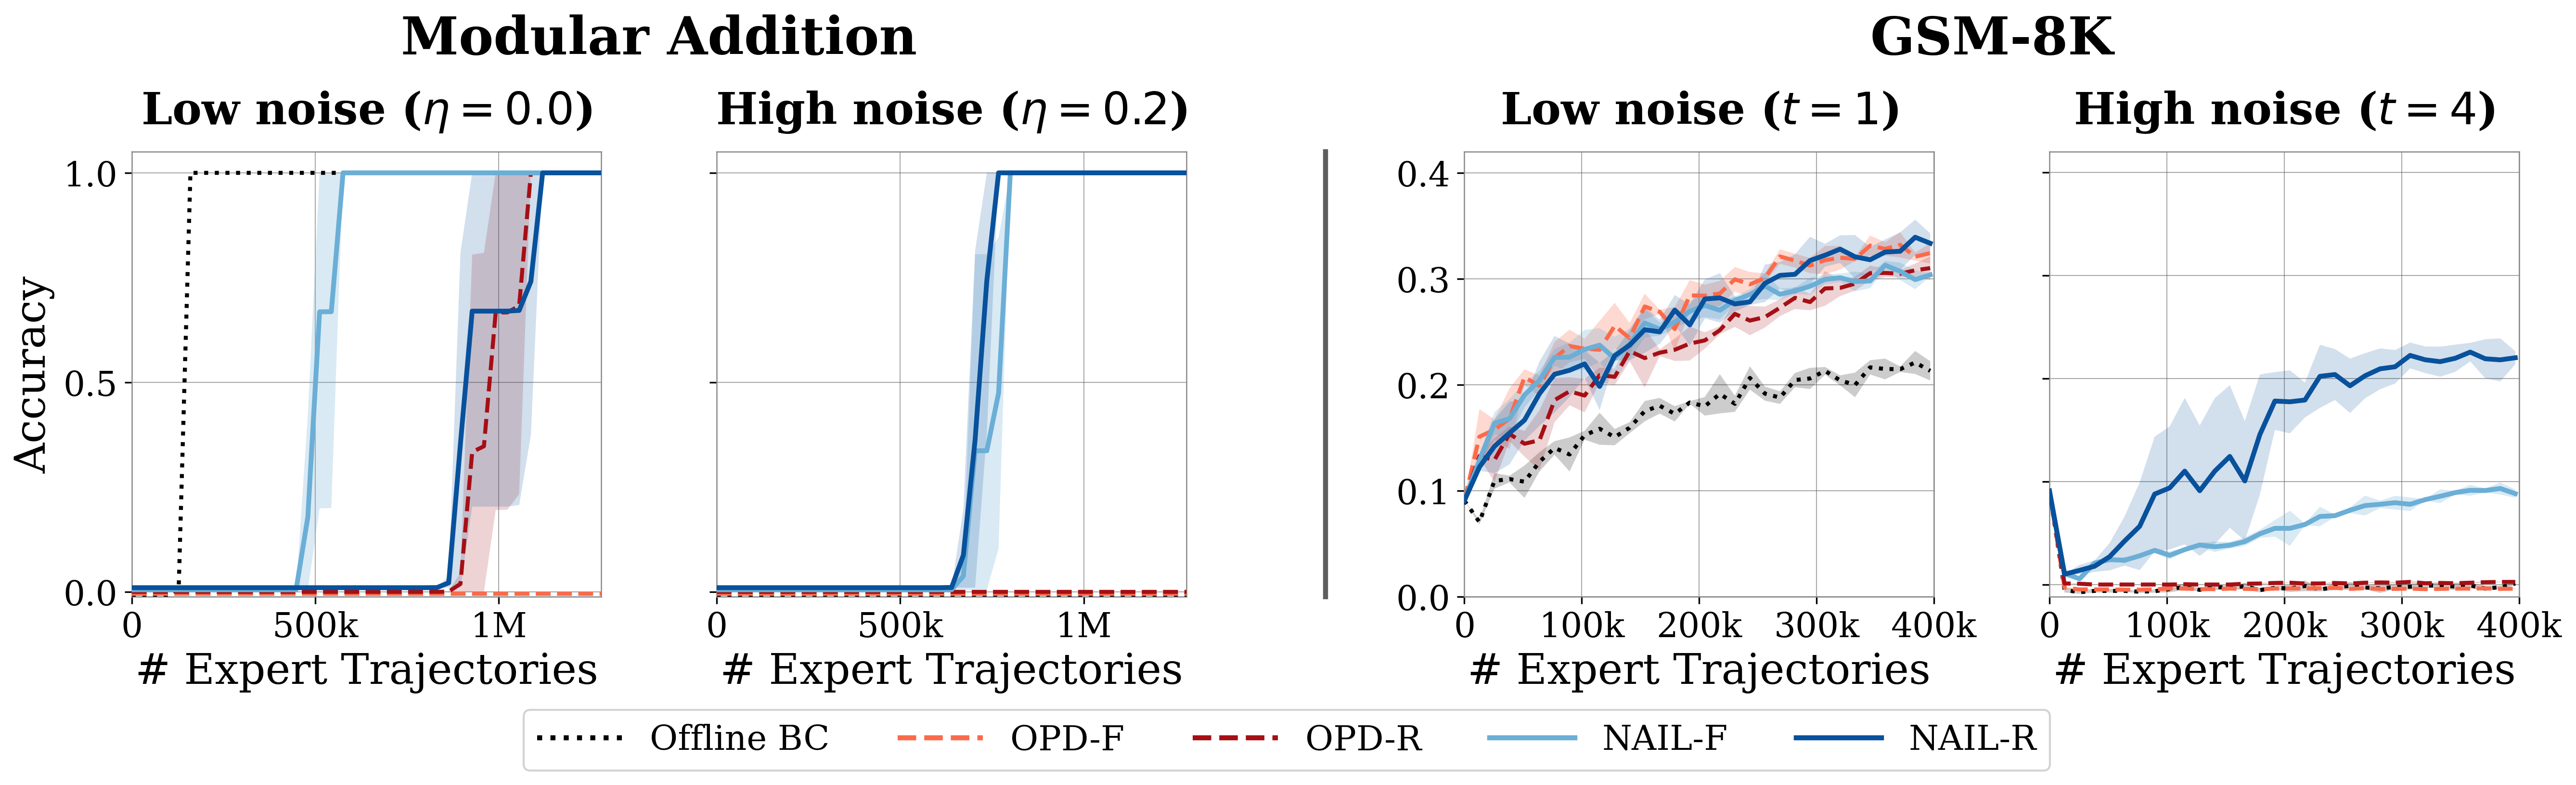

In [68]:
def km_formatter(x, _pos):
    if x == 0:
        return "0"
    if x >= 1e6:
        return f"{x/1e6:g}M"
    return f"{x/1000:g}k"


# Untrained gemma-3-270m-it greedy GSM8K accuracy (~9.1%) — the "Student" baseline.
STUDENT_BASELINE = 0.0909

plot_methods(
    panel_data=panel_data,
    panel_loader=panel_loader,
    panel_titles=panel_titles,
    nrows=1, ncols=4,
    panel_xlim={(0, 0): (0, 20000 * 64), (0, 1): (0, 20000 * 64),
                (0, 2): (0, 400000), (0, 3): (0, 400000)},
    panel_ylabel={(0, 0): "Accuracy"},
    panel_ylim={(0, 0): (-0.012, 1.05), (0, 1): (-0.012, 1.05),
                (0, 2): (-0.0, 0.42), (0, 3): (-0.012, 0.42)},
    panel_yticks={(0, 0): [0.0, 0.5, 1.0],
                  (0, 1): [0.0, 0.5, 1.0],
                  (0, 2): [0.0, 0.1, 0.2, 0.3, 0.4],
                  (0, 3): [0.0, 0.1, 0.2, 0.3, 0.4]},
    panel_hide_yticklabels=[(0, 1), (0, 3)],
    # x ← step × 64 ≈ # expert trajectories seen (effective batch size = 64).
    panel_xmul={(0, 0): 64, (0, 1): 64, (0, 2): 64, (0, 3): 64},
    panel_xformatter={(0, 0): km_formatter, (0, 1): km_formatter,
                      (0, 2): km_formatter, (0, 3): km_formatter},
    panel_xlabel={(0, 0): "# Expert Trajectories", (0, 1): "# Expert Trajectories",
                  (0, 2): "# Expert Trajectories", (0, 3): "# Expert Trajectories"},
    col_separator_after=[1],
    col_separator_pos=0.50,
    col_group_gap_ratio=0.1,
    legend_bbox_to_anchor=(0.5, -0.22),
    group_titles=[(0, 1, "Modular Addition"), (2, 3, "GSM-8K")],
    group_title_y_offset=0.15,
    # Anchor every method curve in the GSM panels at (x=0, y=0-shot accuracy).
    panel_prepend_xy={(0, 2): (0, STUDENT_BASELINE), (0, 3): (0, STUDENT_BASELINE)},
    # panel_baseline={(0, 2): STUDENT_BASELINE, (0, 3): STUDENT_BASELINE},
    # panel_baseline_label={(0, 2): "0-shot", (0, 3): "0-shot"},
    show_dots=False,
    save_fig_path="fig_main.pdf",
    suptitle=None,
)


## ModAdd val loss + accuracy

2×2 figure: top row = validation loss (linear, 0–2 range), bottom row = exact-match accuracy. Columns are low / high noise. Same five methods aggregated across the three modular-addition seeds.

/var/tmp/ipykernel_921167/3168621019.py:108: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 1, 1])


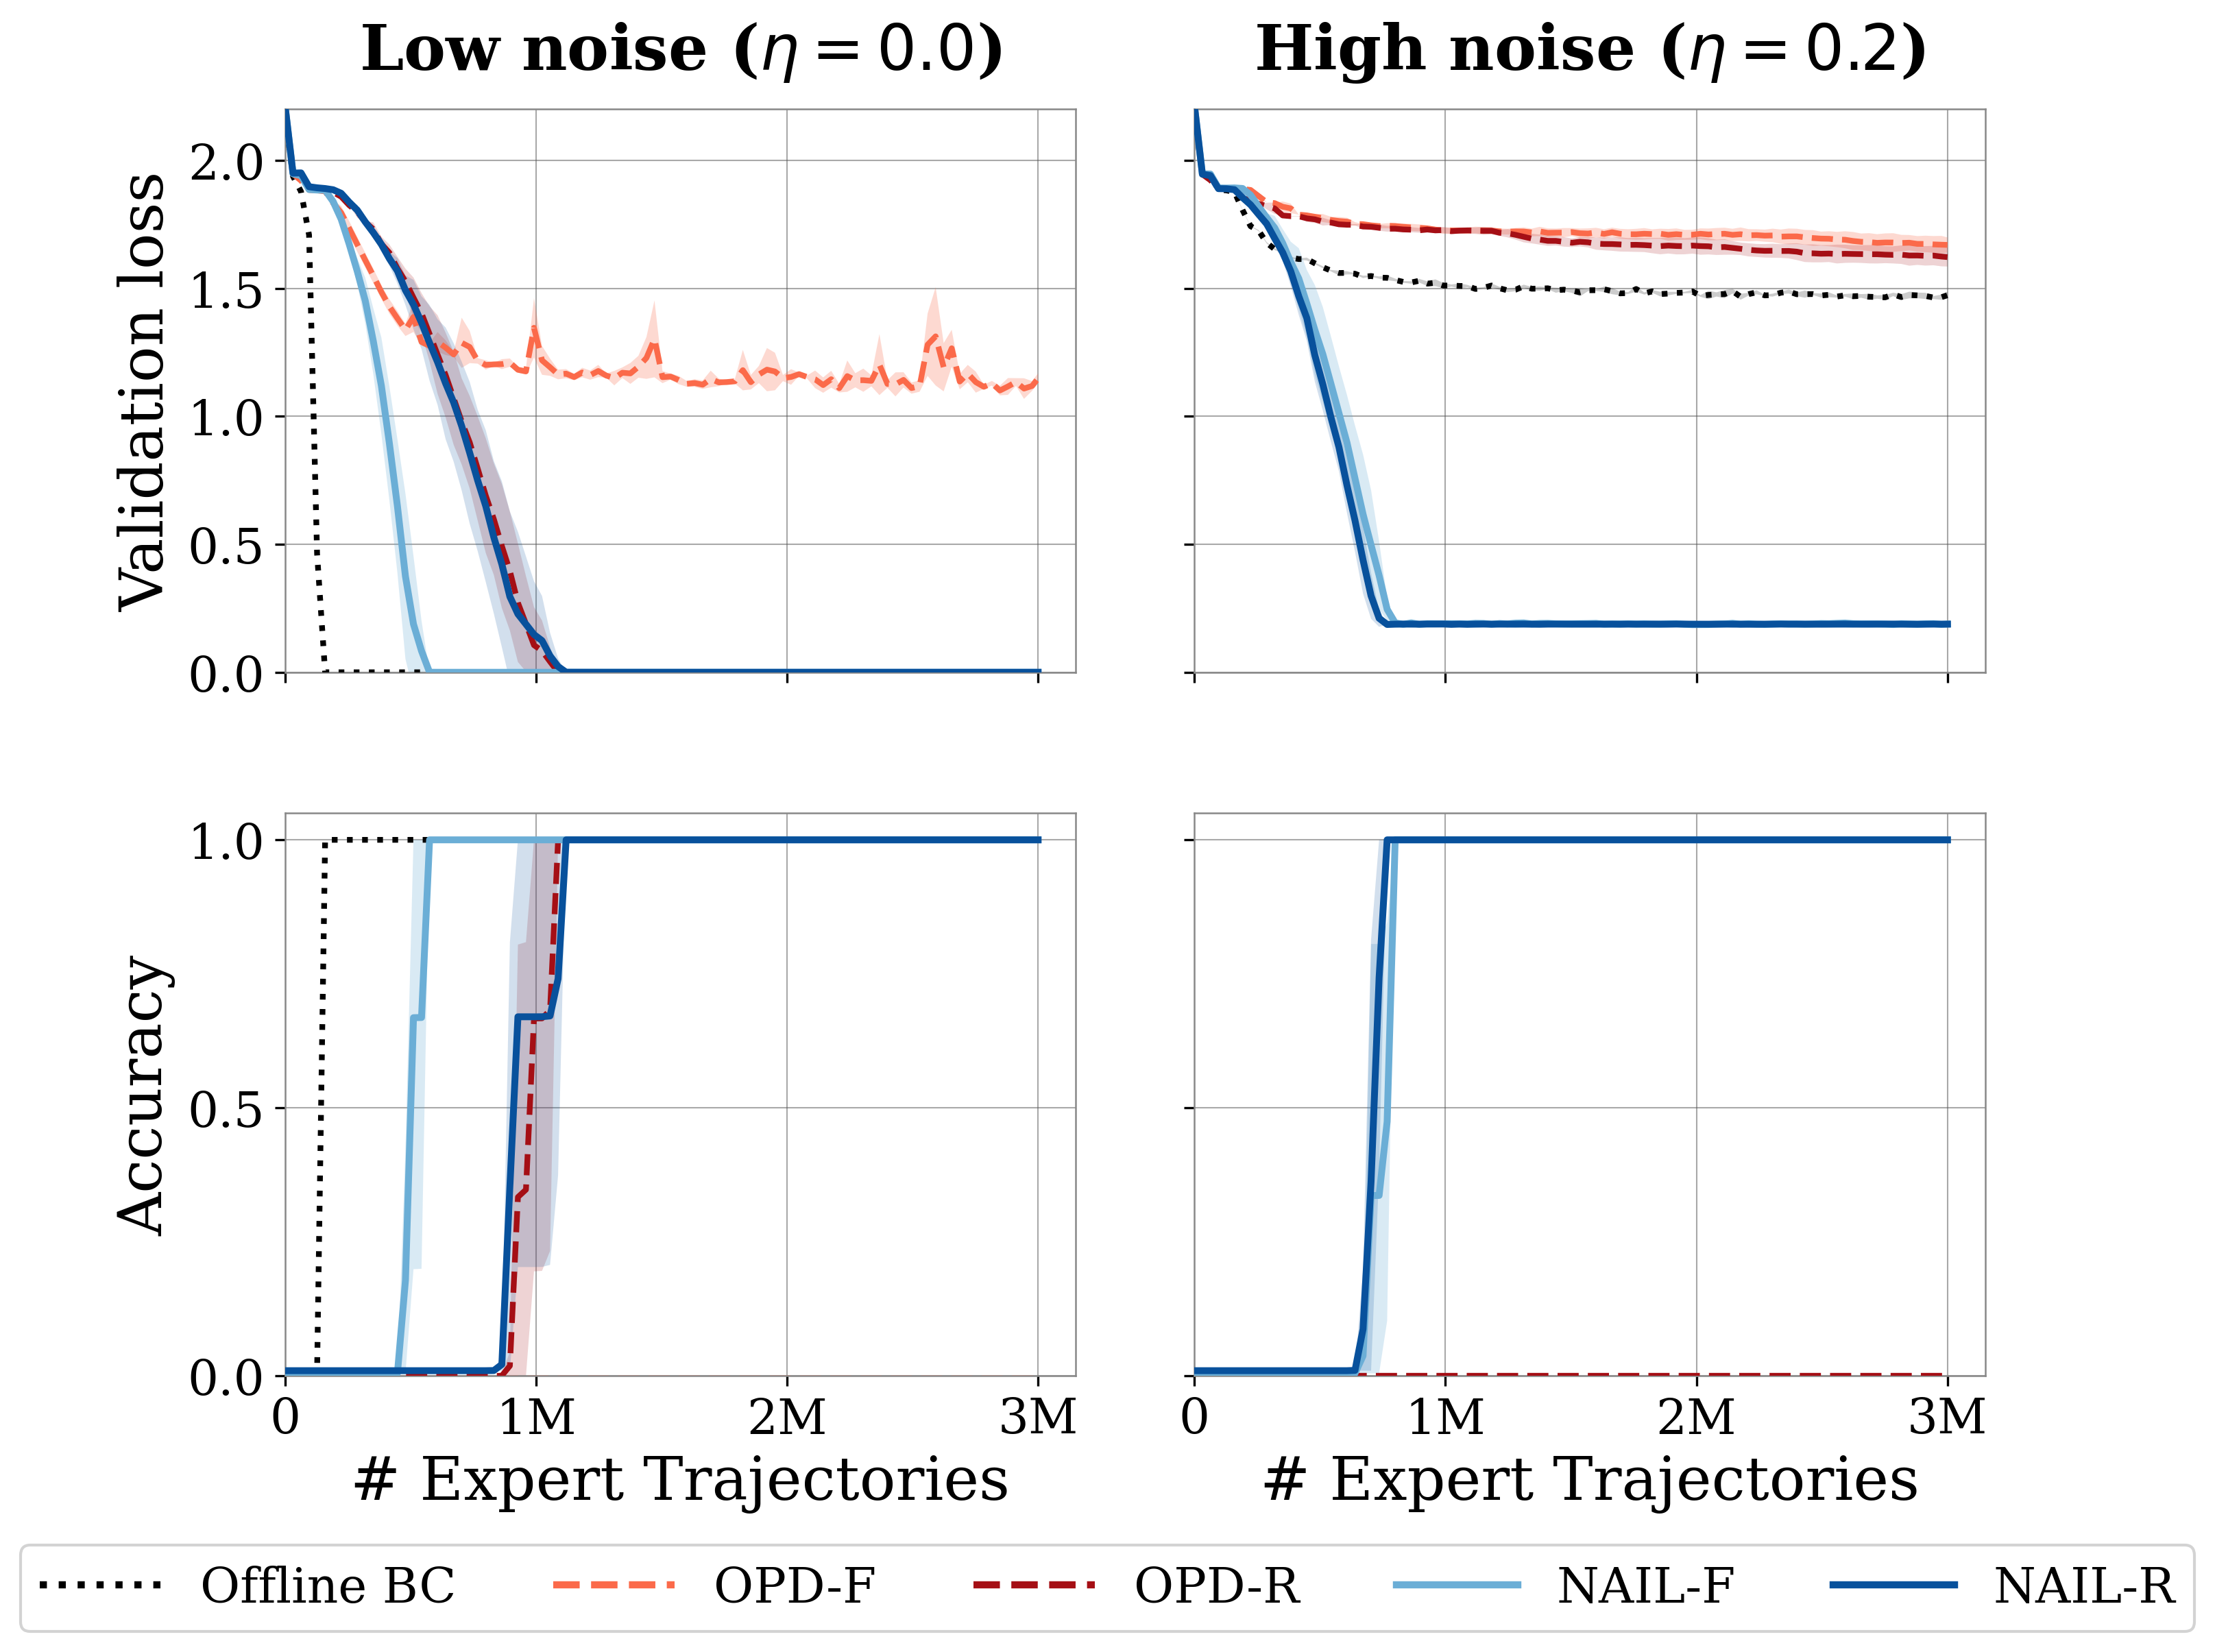

In [69]:
from functools import partial

# Loader for val loss (tries `val` first, then `val/loss`).
load_val_loss = partial(load_eval_history, y_fields=("val", "val/loss"))


def plot_modadd_loss_and_acc(
    save_fig_path: str = None,
    xmul: int = 64,
    figsize: tuple = (16/3 * 2, 4 * 2),
    legend_bbox_to_anchor: tuple = (0.5, -0.06),
    loss_ylim: tuple = (-0.00, 2.2),
    acc_ylim: tuple = (-0.00, 1.05),
    xlim: tuple = (0, None),   # (lo, hi) applied to every panel; default anchors at 0
    wspace: float = 0.15,
    hspace: float = 0.25,
):
    """2×2 plot. Top row = ModAdd val loss; bottom row = ModAdd accuracy.
    Columns: low noise (eta=0.0), high noise (eta=0.2)."""
    eta_panels = [
        ("Low noise ($\\eta=0.0$)", modadd_panel("eta0p0")),
        ("High noise ($\\eta=0.2$)", modadd_panel("eta0p2")),
    ]

    fig, axes = plt.subplots(
        2, 2,
        figsize=figsize,
        sharey="row",
        gridspec_kw={"wspace": wspace, "hspace": hspace},
    )
    seen = []

    for c, (title, methods) in enumerate(eta_panels):
        for r, mode in enumerate(("loss", "acc")):
            ax = axes[r, c]
            for spine in ax.spines.values():
                spine.set_linewidth(0.6); spine.set_color("#888")

            loader = load_val_loss if mode == "loss" else load_eval_history

            for method_name in METHOD_ORDER:
                seed_map = methods.get(method_name, {})
                if not seed_map:
                    continue
                xs, mean, std = aggregate_seeds(seed_map, loader=loader)
                if xs is None:
                    continue
                xs = np.asarray(xs, dtype=float) * xmul
                mean = np.asarray(mean, dtype=float)
                std = np.asarray(std, dtype=float)
                style = METHOD_STYLE[method_name]
                color = style["color"]
                ci_alpha = style.get("ci_alpha", 0.20)

                if mode == "acc":
                    # Clamp CI to [0, 1] then apply the per-method y_offset taper
                    # so coincident curves at 0 / 1 stay distinguishable.
                    y_off = style.get("y_offset", 0.0)
                    lb = np.clip(mean - std, 0.0, 1.0)
                    ub = np.clip(mean + std, 0.0, 1.0)
                    taper = lambda y: y + y_off * (1.0 - y)
                    mean_plot = taper(mean)
                    lb_plot = taper(lb)
                    ub_plot = taper(ub)
                else:
                    mean_plot = mean
                    lb_plot = mean - std
                    ub_plot = mean + std

                ax.plot(xs, mean_plot, color=color, lw=style["linewidth"],
                        ls=style["linestyle"], zorder=3)
                ax.fill_between(xs, lb_plot, ub_plot,
                                facecolor=color, alpha=ci_alpha,
                                edgecolor="none", linewidth=0.0, zorder=2)

                if method_name not in seen:
                    seen.append(method_name)

            # Per-panel cosmetics.
            if r == 0:
                ax.set_title(title, fontweight="bold", fontsize=TITLE_FONTSIZE)
                ax.set_ylim(*loss_ylim)
                if c == 0:
                    ax.set_ylabel("Validation loss", fontsize=LABEL_FONTSIZE)
                ax.tick_params(axis="x", labelbottom=False)  # x labels only on bottom row
            else:  # accuracy
                ax.set_ylim(*acc_ylim)
                ax.yaxis.set_major_locator(FixedLocator([0.0, 0.5, 1.0]))
                ax.yaxis.set_major_formatter(FormatStrFormatter("%.1f"))
                ax.set_xlabel("# Expert Trajectories", fontsize=LABEL_FONTSIZE)
                if c == 0:
                    ax.set_ylabel("Accuracy", fontsize=LABEL_FONTSIZE)

            if xlim is not None:
                ax.set_xlim(*xlim)
            ax.tick_params(axis="both", labelsize=TICK_FONTSIZE)
            if c == 1:
                ax.tick_params(axis="y", labelleft=False)
            ax.xaxis.set_major_formatter(FuncFormatter(km_formatter))

    handles = [Line2D([0], [0], color=METHOD_STYLE[m]["color"],
                      ls=METHOD_STYLE[m]["linestyle"], lw=2.5, label=m)
               for m in seen]
    fig.legend(handles=handles, loc="lower center", ncol=len(handles),
               frameon=True, framealpha=0.85, fontsize=LEGEND_FONTSIZE,
               handlelength=2.5, bbox_to_anchor=legend_bbox_to_anchor)

    plt.tight_layout(rect=[0, 0.03, 1, 1])
    if save_fig_path:
        plt.savefig(save_fig_path, bbox_inches="tight", dpi=300)
        print(f"Saved: {save_fig_path}")
    plt.show()


plot_modadd_loss_and_acc()


Saved: fig_modadd_details.pdf


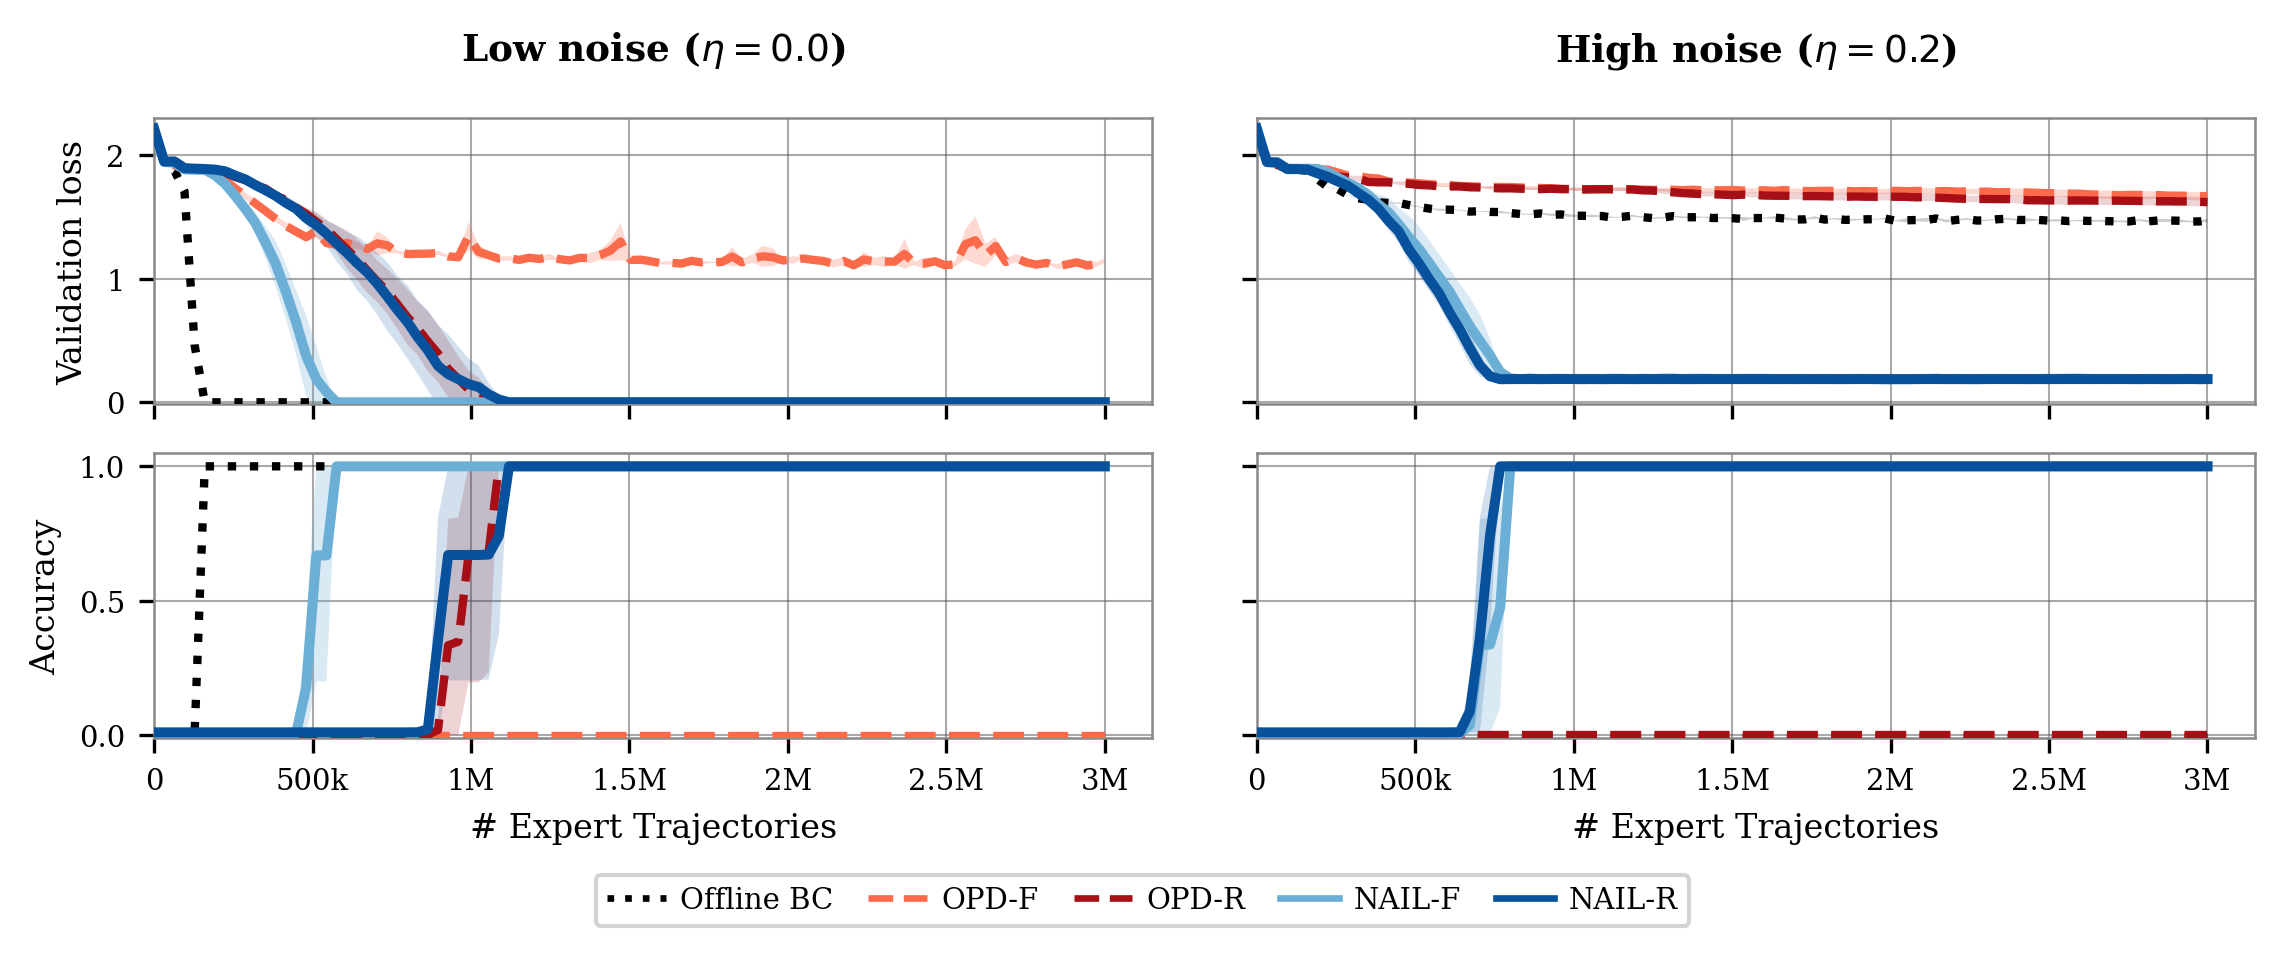

In [70]:
from functools import partial

# Loader for val loss (tries `val` first, then `val/loss`).
load_val_loss = partial(load_eval_history, y_fields=("val", "val/loss"))


def plot_modadd_loss_and_acc(
    save_fig_path: str = None,
    xmul: int = 64,
    figsize: tuple = (7.5, 2.8),                  # wider for long legend, scaled to \linewidth in LaTeX
    legend_bbox_to_anchor: tuple = (0.5, -0.10),
    loss_ylim: tuple = (-0.012, 2.3),
    acc_ylim: tuple = (-0.012, 1.05),
    xlim: tuple = (0, None),   # (lo, hi) applied to every panel; default anchors at 0
    wspace: float = 0.08,
    hspace: float = 0.08,
):
    """2×2 plot. Top row = ModAdd val loss; bottom row = ModAdd accuracy.
    Columns: low noise (eta=0.0), high noise (eta=0.2)."""
    # Font sizes tuned for ~7.5" wide figure scaled to \linewidth.
    TITLE_FONTSIZE  = 9
    LABEL_FONTSIZE  = 8
    TICK_FONTSIZE   = 7
    LEGEND_FONTSIZE = 7

    eta_panels = [
        ("Low noise ($\\eta=0.0$)", modadd_panel("eta0p0")),
        ("High noise ($\\eta=0.2$)", modadd_panel("eta0p2")),
    ]

    fig, axes = plt.subplots(
        2, 2,
        figsize=figsize,
        sharey="row",
        sharex="col",
        layout="constrained",
        gridspec_kw={"wspace": wspace, "hspace": hspace},
    )
    seen = []

    for c, (title, methods) in enumerate(eta_panels):
        for r, mode in enumerate(("loss", "acc")):
            ax = axes[r, c]
            for spine in ax.spines.values():
                spine.set_linewidth(0.6); spine.set_color("#888")

            loader = load_val_loss if mode == "loss" else load_eval_history

            for method_name in METHOD_ORDER:
                seed_map = methods.get(method_name, {})
                if not seed_map:
                    continue
                xs, mean, std = aggregate_seeds(seed_map, loader=loader)
                if xs is None:
                    continue
                xs = np.asarray(xs, dtype=float) * xmul
                mean = np.asarray(mean, dtype=float)
                std = np.asarray(std, dtype=float)
                style = METHOD_STYLE[method_name]
                color = style["color"]
                ci_alpha = style.get("ci_alpha", 0.20)

                if mode == "acc":
                    # Clamp CI to [0, 1] then apply the per-method y_offset taper
                    # so coincident curves at 0 / 1 stay distinguishable.
                    y_off = style.get("y_offset", 0.0)
                    lb = np.clip(mean - std, 0.0, 1.0)
                    ub = np.clip(mean + std, 0.0, 1.0)
                    taper = lambda y: y + y_off * (1.0 - y)
                    mean_plot = taper(mean)
                    lb_plot = taper(lb)
                    ub_plot = taper(ub)
                else:
                    mean_plot = mean
                    lb_plot = mean - std
                    ub_plot = mean + std

                ax.plot(xs, mean_plot, color=color, lw=style["linewidth"],
                        ls=style["linestyle"], zorder=3)
                ax.fill_between(xs, lb_plot, ub_plot,
                                facecolor=color, alpha=ci_alpha,
                                edgecolor="none", linewidth=0.0, zorder=2)

                if method_name not in seen:
                    seen.append(method_name)

            # Per-panel cosmetics.
            if r == 0:
                ax.set_title(title, fontweight="bold", fontsize=TITLE_FONTSIZE)
                ax.set_ylim(*loss_ylim)
                if c == 0:
                    ax.set_ylabel("Validation loss", fontsize=LABEL_FONTSIZE)
                ax.tick_params(axis="x", labelbottom=False)  # x labels only on bottom row
            else:  # accuracy
                ax.set_ylim(*acc_ylim)
                ax.yaxis.set_major_locator(FixedLocator([0.0, 0.5, 1.0]))
                ax.yaxis.set_major_formatter(FormatStrFormatter("%.1f"))
                ax.set_xlabel("# Expert Trajectories", fontsize=LABEL_FONTSIZE)
                if c == 0:
                    ax.set_ylabel("Accuracy", fontsize=LABEL_FONTSIZE)

            if xlim is not None:
                ax.set_xlim(*xlim)
            ax.tick_params(axis="both", labelsize=TICK_FONTSIZE)
            if c == 1:
                ax.tick_params(axis="y", labelleft=False)
            ax.xaxis.set_major_formatter(FuncFormatter(km_formatter))

    # Single-row legend, methods in METHOD_ORDER.
    handles = [Line2D([0], [0], color=METHOD_STYLE[m]["color"],
                      ls=METHOD_STYLE[m]["linestyle"], lw=1.6, label=m)
               for m in seen]
    fig.legend(
        handles=handles, loc="lower center", ncol=len(handles),
        frameon=True, framealpha=0.85, fontsize=LEGEND_FONTSIZE,
        handlelength=2.0, handletextpad=0.5, columnspacing=1.2,
        borderpad=0.4, bbox_to_anchor=legend_bbox_to_anchor,
    )

    if save_fig_path:
        plt.savefig(save_fig_path, bbox_inches="tight")
        print(f"Saved: {save_fig_path}")
    plt.show()


plot_modadd_loss_and_acc(save_fig_path="fig_modadd_details.pdf")

In [71]:
import re

GSM_LOGS_DIR = Path("/home/peihanliu/noisydistil/nopd/gsm/logs")

# OBC (HF Trainer) prints the eval dict in-line:
#   {'eval_loss': '1.854', 'eval_runtime': '16.53', ..., 'epoch': '0.032'}
RE_OBC_EVAL = re.compile(r"\{'eval_loss': '([0-9.eE+-]+)'.*?'epoch': '([0-9.eE+-]+)'\}")

# SOPD / TM-OPD custom loop:
#   Saved to .../checkpoint-200
#   ...
#   GSM8K eval_loss: 1.9792 (n=1319)
RE_CKPT_SAVED = re.compile(r"checkpoint-(\d+)")
RE_GSM_EVAL = re.compile(r"GSM8K eval_loss:\s*([0-9.eE+-]+)")

# tqdm fragment "X/Y [..." appears for both train and eval bars; the training one
# has the largest Y, so take the max.
RE_TQDM_TOTAL = re.compile(r"\b\d+/(\d+)\b\s*\[")
RE_STEP_TOTAL = re.compile(r"Step \d+/(\d+)")


def find_total_steps(text: str):
    matches = [int(m.group(1)) for m in RE_TQDM_TOTAL.finditer(text)]
    if matches:
        return max(matches)
    m = RE_STEP_TOTAL.search(text)
    return int(m.group(1)) if m else None


def parse_gsm_eval_loss(log_path: Path):
    """Parse {step: eval_loss} from a GSM training log.

    Handles both HF-Trainer dict logs (OBC) and the custom-loop "GSM8K eval_loss"
    lines (SOPD / TM-OPD). Returns None if the log doesn't exist or is empty.
    """
    if not log_path.exists():
        return None
    text = log_path.read_text(errors="ignore")
    out = {}

    # Format 1: HF Trainer eval dict — {'eval_loss': '...', 'epoch': '...'}.
    total = find_total_steps(text)
    if total:
        for m in RE_OBC_EVAL.finditer(text):
            loss = float(m.group(1))
            epoch = float(m.group(2))
            step = round(epoch * total)
            out[step] = loss

    # Format 2: each "GSM8K eval_loss:" is preceded by a "Saved to .../checkpoint-NNN" line.
    last_ckpt = None
    for line in text.splitlines():
        if "Saved to" in line:
            cm = RE_CKPT_SAVED.search(line)
            if cm:
                last_ckpt = int(cm.group(1))
                continue
        em = RE_GSM_EVAL.search(line)
        if em and last_ckpt is not None:
            out[last_ckpt] = float(em.group(1))
            last_ckpt = None  # consume

    return out if out else None


def gsm_log_path_from_run_dir(run_dir):
    """Map a GSM run directory to its training log file in gsm/logs/."""
    return GSM_LOGS_DIR / f"{Path(run_dir).name}.log"


# Build {(method, noise, seed): {step: loss}} for all 30 runs.
gsm_eval_loss = {}
for (method, noise), tmpl in GSM_RUN_TMPL.items():
    for seed in GSM_SEEDS:
        run_dir = str(tmpl).format(seed=seed)
        log = gsm_log_path_from_run_dir(run_dir)
        gsm_eval_loss[(method, noise, seed)] = parse_gsm_eval_loss(log)

# Summary print.
print(f"{'method':<12} {'noise':<6}  per-seed (n_points)")
for (method, noise) in GSM_RUN_TMPL.keys():
    cells = []
    for seed in GSM_SEEDS:
        d = gsm_eval_loss[(method, noise, seed)]
        cells.append(f"{seed}={'—' if d is None else len(d)}")
    print(f"  {method:<10} {noise:<6}  " + "  ".join(cells))


method       noise   per-seed (n_points)
  Offline BC clean   42=32  43=32  44=32
  Offline BC noisy   42=32  43=32  44=32
  NAIL-F     clean   42=31  43=31  44=31
  NAIL-F     noisy   42=31  43=31  44=31
  NAIL-R     clean   42=31  43=31  44=31
  NAIL-R     noisy   42=31  43=31  44=31
  OPD-F      clean   42=—  43=31  44=31
  OPD-F      noisy   42=31  43=31  44=31
  OPD-R      clean   42=31  43=31  44=31
  OPD-R      noisy   42=31  43=31  44=31


## GSM8K test loss

Parsed from the training logs (HF Trainer eval dict for OBC; `GSM8K eval_loss:` line for SOPD / TM-OPD). 1×2 layout — low / high noise — five methods with mean ± std across seeds. Per-panel y-range is auto-scaled because clean (~2) and noisy (~5–10) live on very different magnitudes.

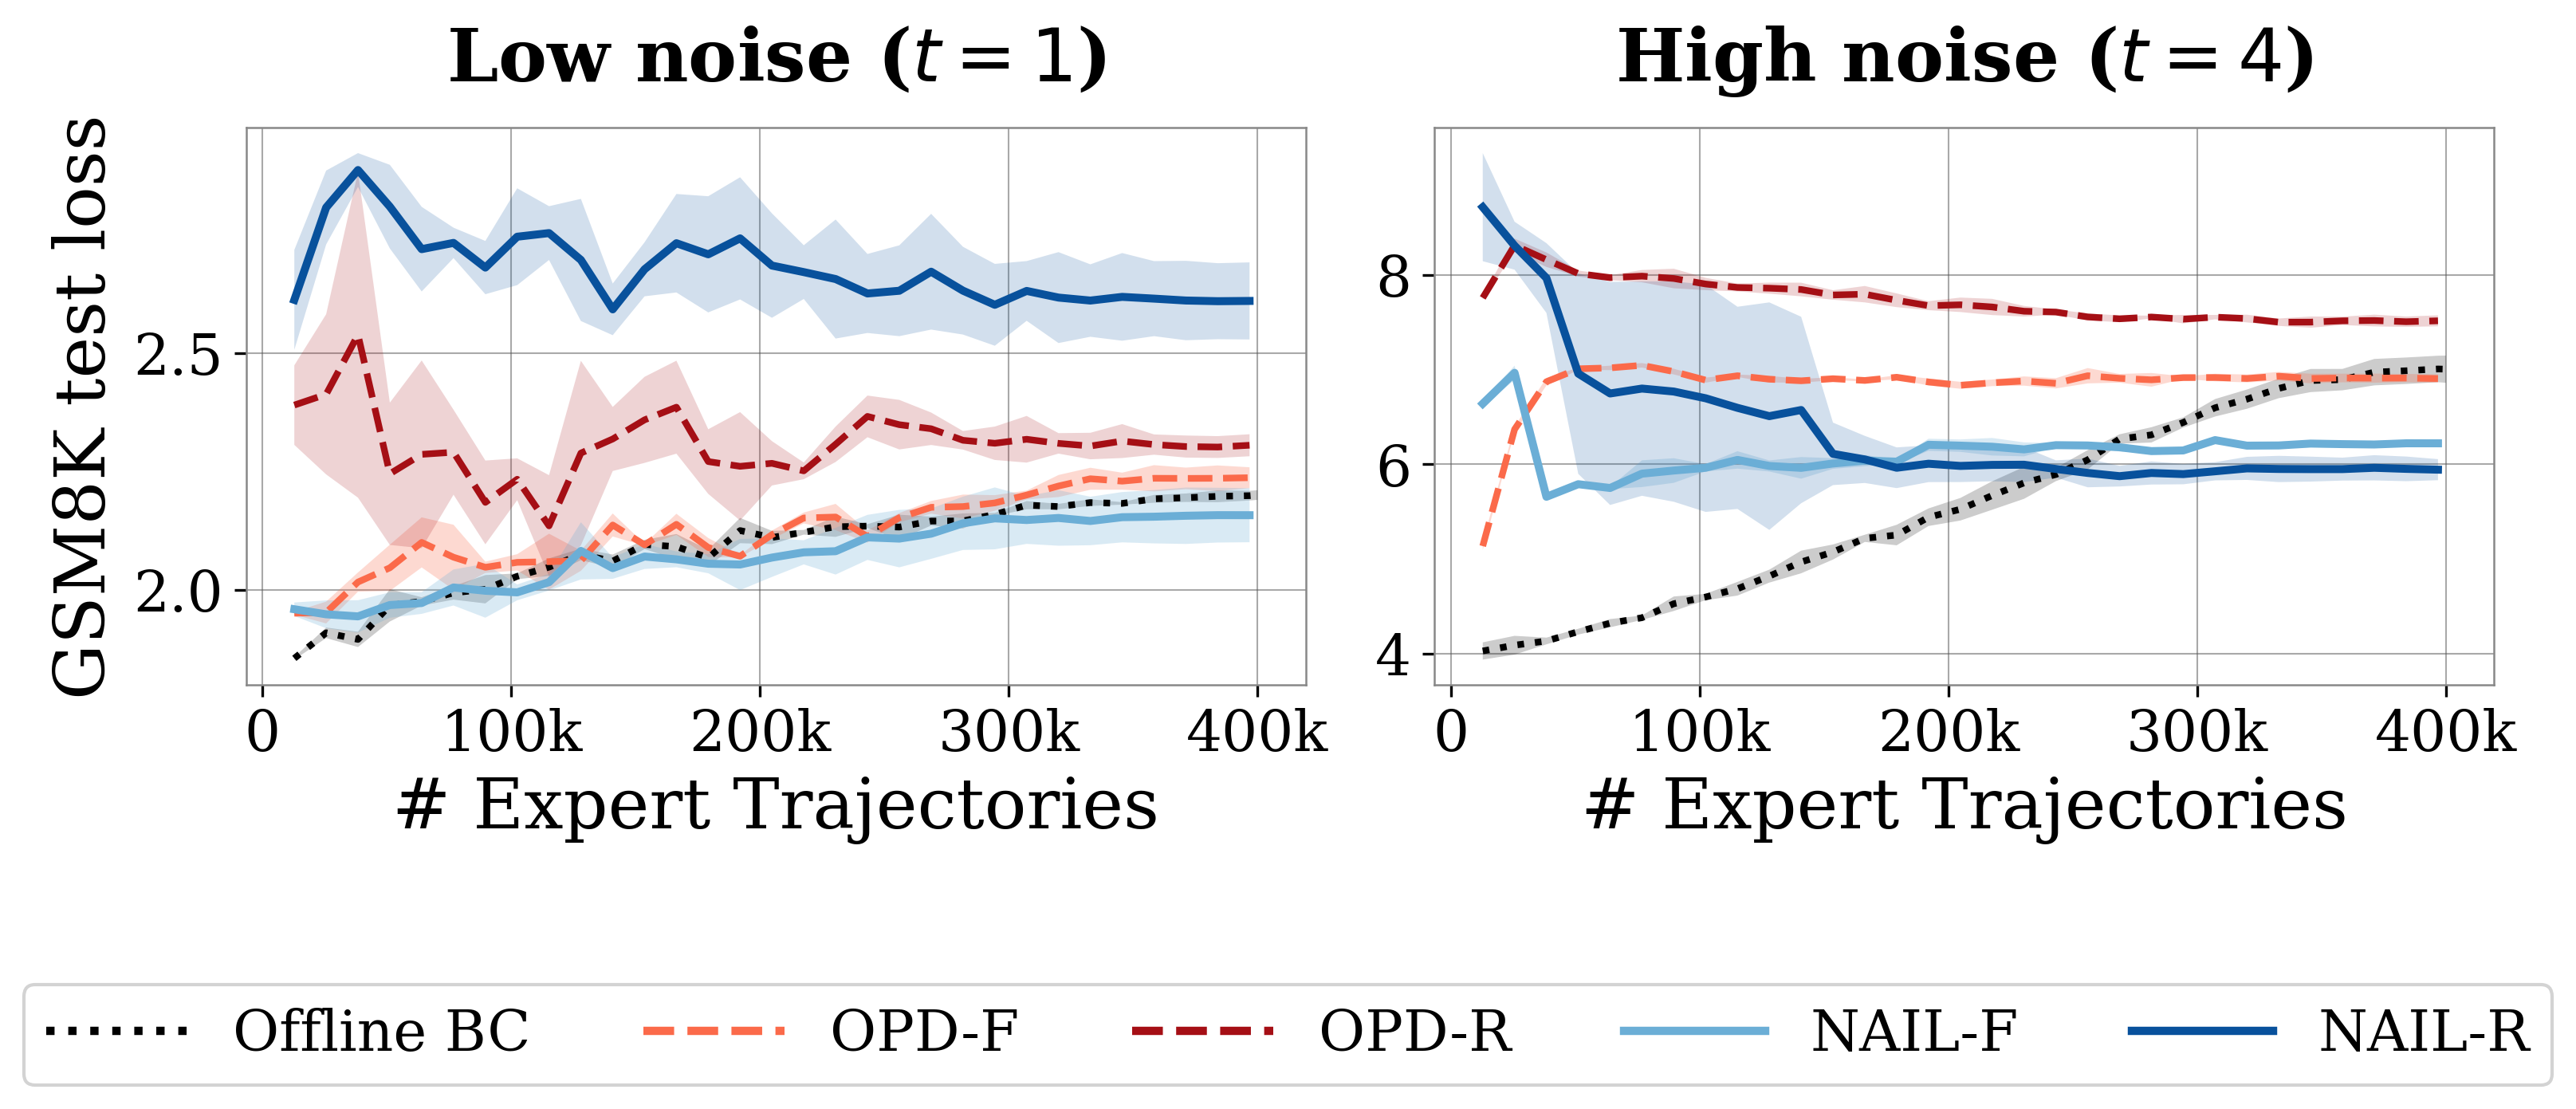

In [72]:
def plot_gsm_test_loss(
    save_fig_path: str = None,
    xmul: int = 64,
    figsize: tuple = (16/3 * 2, 4),
    legend_bbox_to_anchor: tuple = (0.5, -0.18),
    ylim: dict = None,         # {(0, c): (lo, hi)} — per-panel; default auto-scale
    yscale: str = "linear",
):
    """1×2 plot of GSM8K test loss (low / high noise) read from `gsm_eval_loss`."""
    panels = {
        0: ("Low noise ($t=1$)",  "clean"),
        1: ("High noise ($t=4$)", "noisy"),
    }
    ylim = ylim or {}

    fig, axes = plt.subplots(1, 2, figsize=figsize, sharey=False)
    seen = []

    for c, (title, noise) in panels.items():
        ax = axes[c]
        for spine in ax.spines.values():
            spine.set_linewidth(0.6); spine.set_color("#888")

        for method_name in METHOD_ORDER:
            # Gather per-seed dicts that actually have data.
            per_seed = {
                seed: d for seed in GSM_SEEDS
                if (d := gsm_eval_loss.get((method_name, noise, seed)))
            }
            if not per_seed:
                continue
            common = sorted(set.intersection(*[set(v) for v in per_seed.values()]))
            if not common:
                continue
            arr = np.array([[per_seed[s][st] for st in common] for s in per_seed])
            xs = np.array(common, dtype=float) * xmul
            mean = arr.mean(axis=0)
            std = arr.std(axis=0)
            lb = mean - std
            ub = mean + std

            style = METHOD_STYLE[method_name]
            ax.plot(xs, mean, color=style["color"], lw=style["linewidth"],
                    ls=style["linestyle"], zorder=3)
            ax.fill_between(xs, lb, ub,
                            facecolor=style["color"], alpha=style.get("ci_alpha", 0.20),
                            edgecolor="none", linewidth=0.0, zorder=2)
            if method_name not in seen:
                seen.append(method_name)

        ax.set_yscale(yscale)
        if (0, c) in ylim:
            ax.set_ylim(*ylim[(0, c)])
        ax.set_title(title, fontweight="bold", fontsize=TITLE_FONTSIZE)
        ax.set_xlabel("# Expert Trajectories", fontsize=LABEL_FONTSIZE)
        if c == 0:
            ax.set_ylabel("GSM8K test loss", fontsize=LABEL_FONTSIZE)
        ax.tick_params(axis="both", labelsize=TICK_FONTSIZE)
        ax.xaxis.set_major_formatter(FuncFormatter(km_formatter))

    handles = [Line2D([0], [0], color=METHOD_STYLE[m]["color"],
                      ls=METHOD_STYLE[m]["linestyle"], lw=2.5, label=m)
               for m in seen]
    fig.legend(handles=handles, loc="lower center", ncol=len(handles),
               frameon=True, framealpha=0.85, fontsize=LEGEND_FONTSIZE,
               handlelength=2.5, bbox_to_anchor=legend_bbox_to_anchor)

    plt.tight_layout(rect=[0, 0.06, 1, 1])
    if save_fig_path:
        plt.savefig(save_fig_path, bbox_inches="tight", dpi=300)
        print(f"Saved: {save_fig_path}")
    plt.show()


plot_gsm_test_loss()


## Ablation: ModAdd β sweep

Sweeps the NAIL mixing weight β ∈ {0.1, 0.25, 0.5, 0.75, 0.9} for ModAdd at low noise (η=0.0) and high noise (η=0.2). 2×2 layout mirrors the main ModAdd loss + accuracy figure: top row = `val/loss`, bottom row = `val/clean_full_exact`, columns = low / high noise. Each line is a β value (mean ± std across 3 seeds).

Data: `/home/peihanliu/NAIL/results/modadd_random_suffix/nail_mixed_beta{β}_eta{η}_seed{s}/eval_history.jsonl`.

/var/tmp/ipykernel_921167/211131708.py:164: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 1, 1])


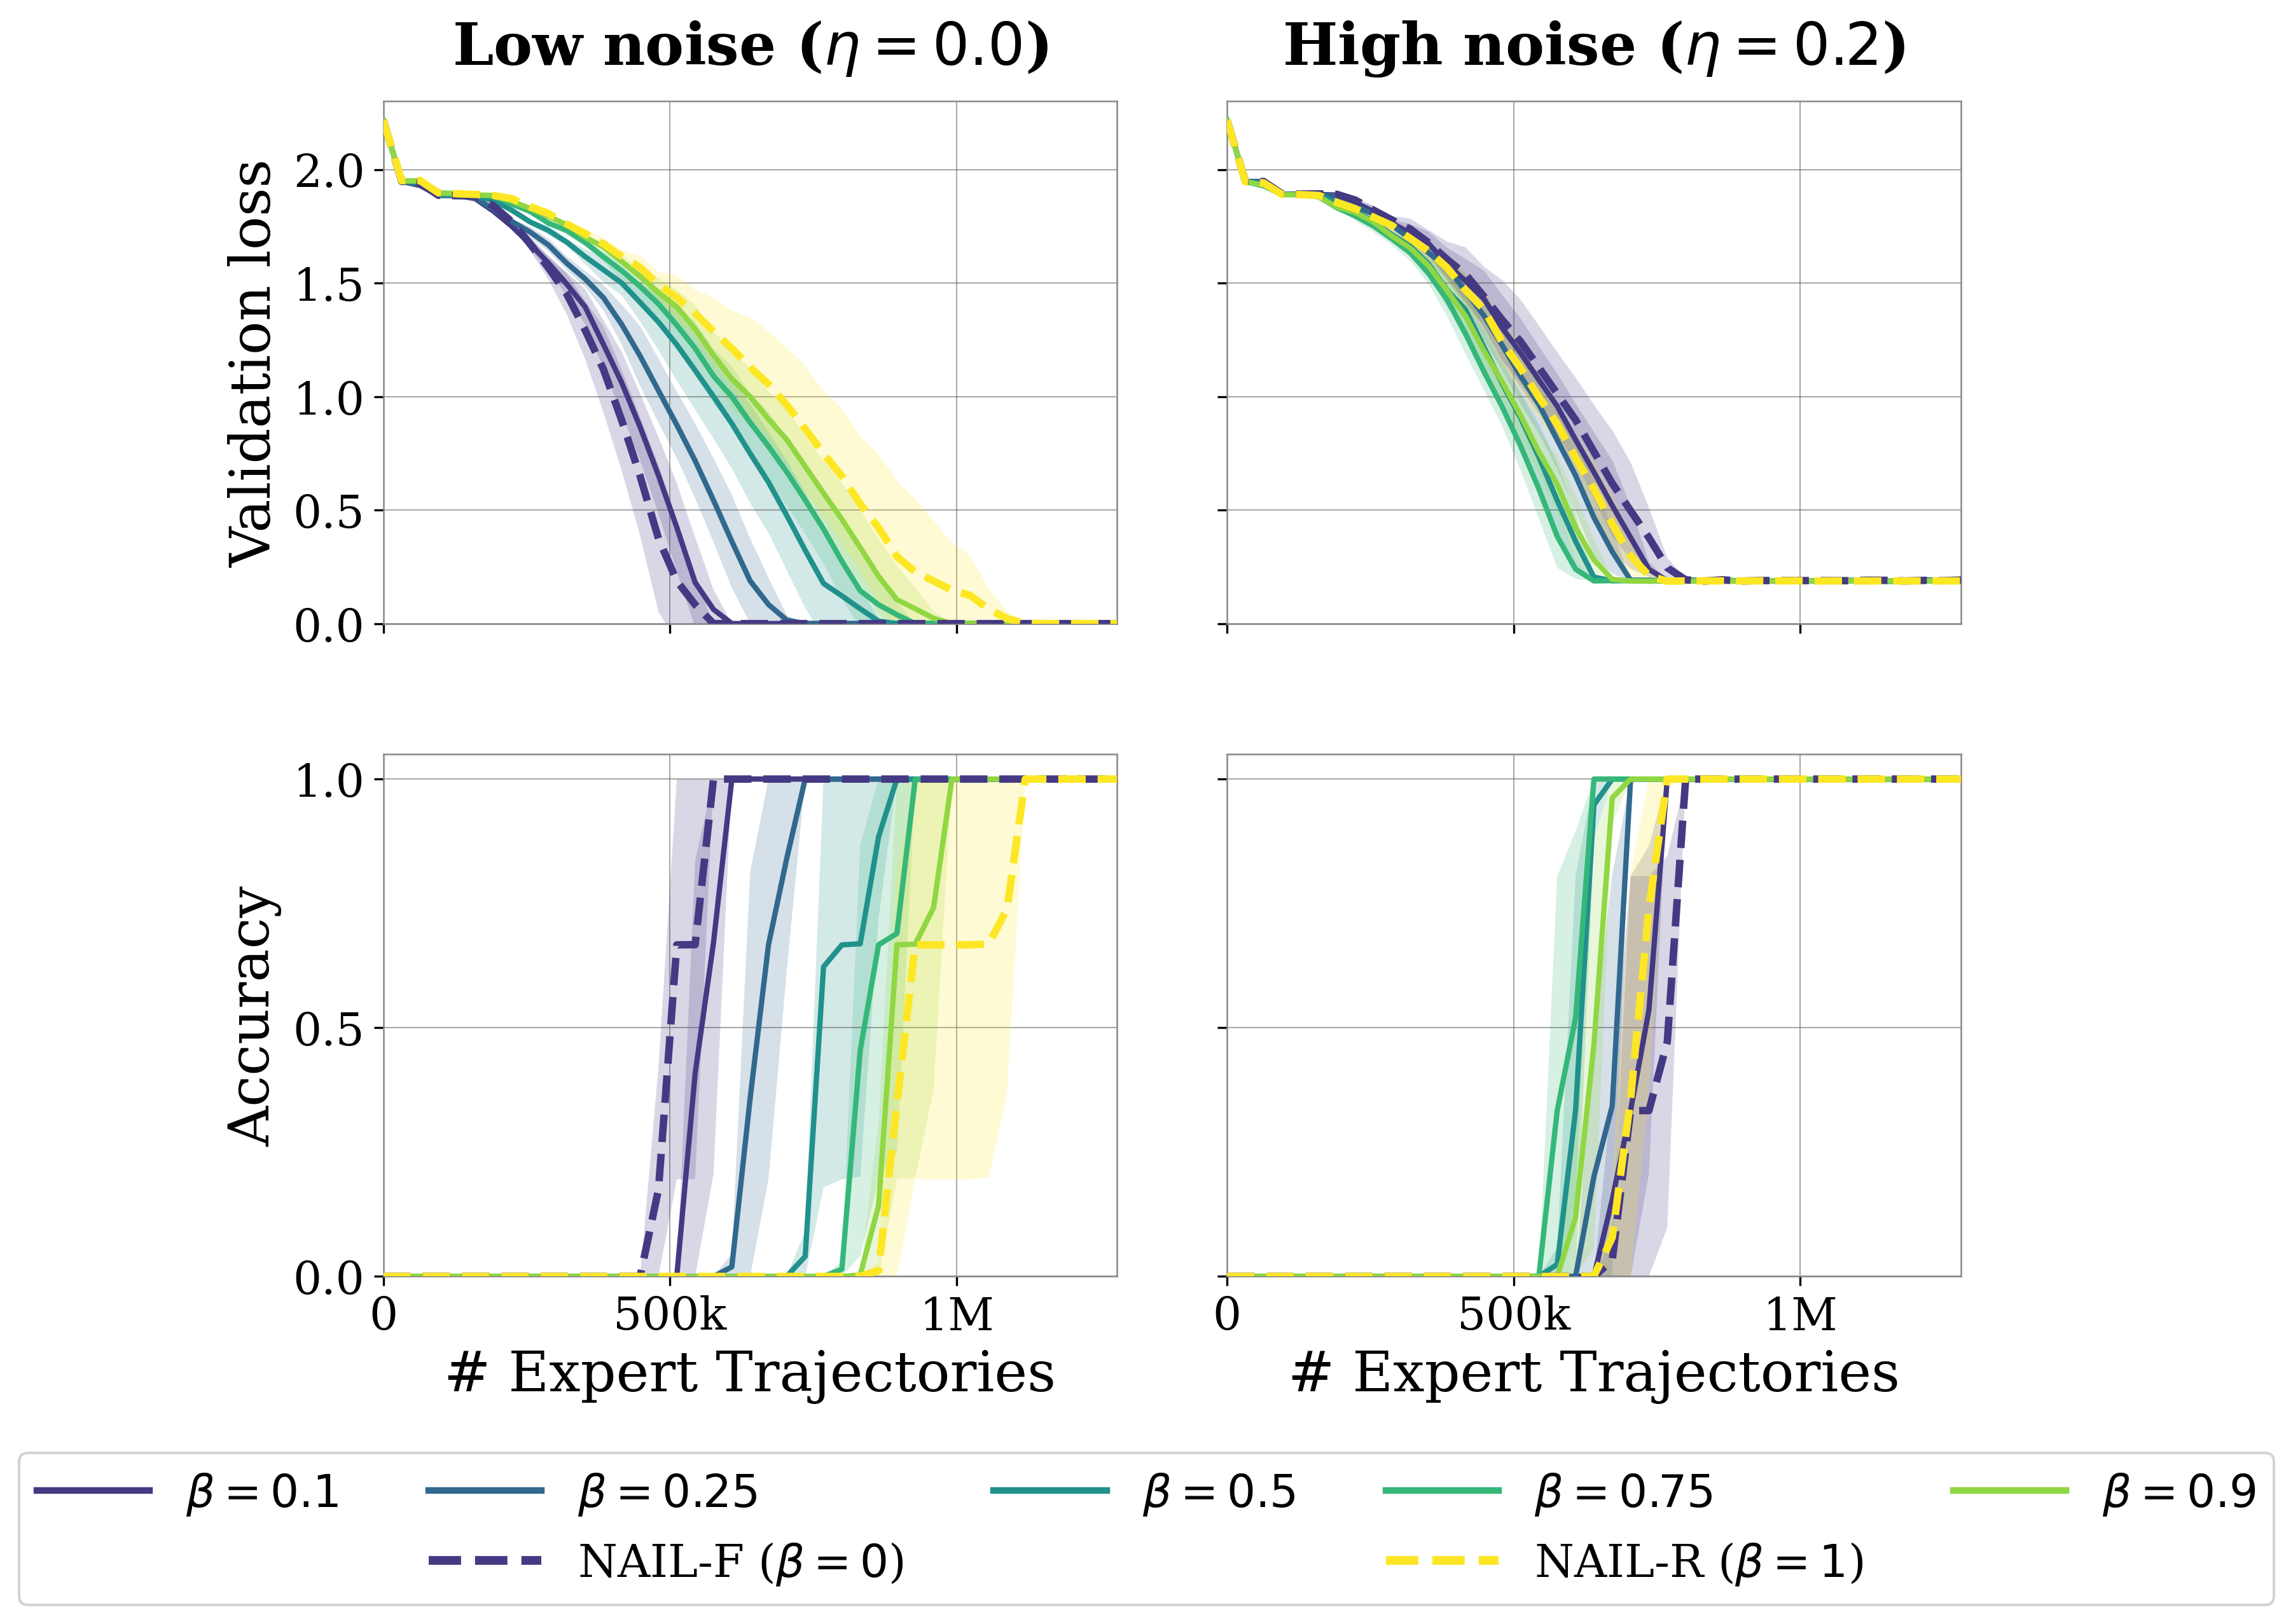

In [73]:
ABLATION_ROOT = Path("/home/peihanliu/NAIL/results/modadd_random_suffix")
ABLATION_SEEDS = [20260417, 20260418, 20260419]
ABLATION_BETAS = [0.1, 0.25, 0.5, 0.75, 0.9]
ABLATION_ETAS = [(0.0, "eta0p0"), (0.2, "eta0p2")]


def beta_str(beta):
    """Format a beta as it appears in the run-dir name (e.g., 0.1 → '0p1')."""
    return f"{beta}".replace(".", "p")


def ablation_run_dir(beta, eta_str, seed):
    return ABLATION_ROOT / f"nail_mixed_beta{beta_str(beta)}_{eta_str}_seed{seed}"


# Loaders for the two y-fields.
load_modadd_loss = partial(load_eval_history, y_fields=("val/loss",))
load_modadd_acc  = partial(load_eval_history, y_fields=("val/clean_full_exact",))


# Color map: viridis sampled at the betas, smaller β → darker/colder.
_cmap = plt.cm.viridis
# BETA_COLORS = {b: _cmap(i / (len(ABLATION_BETAS) - 1)) for i, b in enumerate(ABLATION_BETAS)}

# Two endpoint anchors: NAIL-F (β=0) and NAIL-R (β=1) — drawn with a thicker
# dashed line so they stand out as reference curves vs the β sweep.
NAIL_F_LABEL = r"NAIL-F ($\beta=0$)"
NAIL_R_LABEL = r"NAIL-R ($\beta=1$)"
ANCHOR_LS = "--"
ANCHOR_LW = 2.8
BETA_LS = "-"
BETA_LW = 2.0
# ABLATION_ANCHORS = [
#     # (legend_label, dir_under_results, color, sort_key)
#     (NAIL_F_LABEL, "nail_forward", NAIL_F_COLOR, 0.0),
#     (NAIL_R_LABEL, "nail_reverse", NAIL_R_COLOR, 1.0),
# ]
BETA_COLORS = {b: _cmap((i+1) / (len(ABLATION_BETAS)+2 - 1)) for i, b in enumerate(ABLATION_BETAS)}

ABLATION_ANCHORS = [
    # (legend_label, dir_under_results, color, sort_key)
    (NAIL_F_LABEL, "nail_forward", _cmap((1) / (len(ABLATION_BETAS)+2 - 1)), 0.0),
    (NAIL_R_LABEL, "nail_reverse", _cmap((1+len(ABLATION_BETAS)) / (len(ABLATION_BETAS)+2 - 1)), 1.0),
]


def plot_modadd_beta_ablation(
    save_fig_path: str = None,
    xmul: int = 64,
    figsize: tuple =(16/3 * 2, 4 * 2),
    legend_bbox_to_anchor: tuple = (0.5, -0.12),
    loss_ylim: tuple = (-0.00, 2.3),
    acc_ylim: tuple = (-0.00, 1.05),
    xlim: tuple = None,        # (lo, hi) applied to every panel; None = auto
    wspace: float = 0.15,
    hspace: float = 0.25,
    ci_alpha: float = 0.20,
):
    """2×2 plot. Top row = val/loss; bottom row = val/clean_full_exact (accuracy).
    Columns: low / high noise. One line per β plus NAIL-F/NAIL-R anchors."""
    eta_panels = [
        ("Low noise ($\\eta=0.0$)", "eta0p0"),
        ("High noise ($\\eta=0.2$)", "eta0p2"),
    ]

    fig, axes = plt.subplots(
        2, 2,
        figsize=figsize,
        sharey="row",
        gridspec_kw={"wspace": wspace, "hspace": hspace},
    )

    def _entries_for_eta(eta_str):
        # Each entry is (label, color, sort_key, seed_to_run, ls, lw, is_anchor).
        out = []
        for label, dir_name, color, key in ABLATION_ANCHORS:
            seed_to_run = {
                s: str(MODADD_ROOT / dir_name / f"{eta_str}_seed{s}")
                for s in MODADD_SEEDS
            }
            out.append((label, color, key, seed_to_run, ANCHOR_LS, ANCHOR_LW, True))
        for beta in ABLATION_BETAS:
            seed_to_run = {s: str(ablation_run_dir(beta, eta_str, s)) for s in ABLATION_SEEDS}
            out.append((fr"$\beta={beta:g}$", BETA_COLORS[beta], float(beta),
                        seed_to_run, BETA_LS, BETA_LW, False))
        out.sort(key=lambda e: e[2])
        return out

    seen_handles = {}  # label -> Line2D, deduped across panels

    for c, (title, eta_str) in enumerate(eta_panels):
        entries = _entries_for_eta(eta_str)
        for r, mode in enumerate(("loss", "acc")):
            ax = axes[r, c]
            for spine in ax.spines.values():
                spine.set_linewidth(0.6); spine.set_color("#888")

            loader = load_modadd_loss if mode == "loss" else load_modadd_acc

            for label, color, _key, seed_to_run, ls, lw, is_anchor in entries:
                xs, mean, std = aggregate_seeds(seed_to_run, loader=loader)
                if xs is None:
                    continue
                xs = np.asarray(xs, dtype=float) * xmul
                mean = np.asarray(mean, dtype=float)
                std = np.asarray(std, dtype=float)

                if mode == "acc":
                    lb = np.clip(mean - std, 0.0, 1.0)
                    ub = np.clip(mean + std, 0.0, 1.0)
                else:
                    lb = mean - std
                    ub = mean + std

                ax.plot(xs, mean, color=color, lw=lw, ls=ls,
                        zorder=4 if is_anchor else 3)
                ax.fill_between(xs, lb, ub, facecolor=color, alpha=ci_alpha,
                                edgecolor="none", linewidth=0.0,
                                zorder=2 if is_anchor else 1)

                if label not in seen_handles:
                    seen_handles[label] = Line2D([0], [0], color=color,
                                                 ls=ls, lw=lw + 0.5, label=label)

            # Per-panel cosmetics — same as plot_modadd_loss_and_acc.
            if r == 0:
                ax.set_title(title, fontweight="bold", fontsize=TITLE_FONTSIZE)
                ax.set_ylim(*loss_ylim)
                if c == 0:
                    ax.set_ylabel("Validation loss", fontsize=LABEL_FONTSIZE)
                ax.tick_params(axis="x", labelbottom=False)
            else:
                ax.set_ylim(*acc_ylim)
                ax.yaxis.set_major_locator(FixedLocator([0.0, 0.5, 1.0]))
                ax.yaxis.set_major_formatter(FormatStrFormatter("%.1f"))
                ax.set_xlabel("# Expert Trajectories", fontsize=LABEL_FONTSIZE)
                if c == 0:
                    ax.set_ylabel("Accuracy", fontsize=LABEL_FONTSIZE)

            if xlim is not None:
                ax.set_xlim(*xlim)
            ax.tick_params(axis="both", labelsize=TICK_FONTSIZE)
            if c == 1:
                ax.tick_params(axis="y", labelleft=False)
            ax.xaxis.set_major_formatter(FuncFormatter(km_formatter))

    # Two-row legend (5 cols).
    #   Row 0: β=0.1, β=0.25, β=0.5, β=0.75, β=0.9
    #   Row 1: —, NAIL-F (β=0), —, NAIL-R (β=1), —
    # NAIL-F sits under β=0.25 and NAIL-R under β=0.75 — symmetric around the
    # center column. matplotlib fills the legend column-major, so each
    # column's two slots interleave below.
    empty = Line2D([0], [0], color="none", lw=0, label="")
    n = len(ABLATION_BETAS)  # 5
    nail_f = seen_handles.get(NAIL_F_LABEL, empty)
    nail_r = seen_handles.get(NAIL_R_LABEL, empty)
    row0 = [seen_handles.get(fr"$\beta={b:g}$", empty) for b in ABLATION_BETAS]
    row1 = [empty, nail_f, empty, nail_r, empty]
    interleaved = [h for pair in zip(row0, row1) for h in pair]
    fig.legend(handles=interleaved, loc="lower center", ncol=n,
               frameon=True, framealpha=0.85, fontsize=LEGEND_FONTSIZE,
               handlelength=2.5, bbox_to_anchor=legend_bbox_to_anchor)

    plt.tight_layout(rect=[0, 0.03, 1, 1])
    if save_fig_path:
        plt.savefig(save_fig_path, bbox_inches="tight", dpi=300)
        print(f"Saved: {save_fig_path}")
    plt.show()


# Match the 1×4 panel plot's modadd cutoff: x ∈ [0, 20000 × 64] = [0, 1.28M].
plot_modadd_beta_ablation(xlim=(0, 20000 * 64))


Saved: fig_modadd_mixedkl.pdf


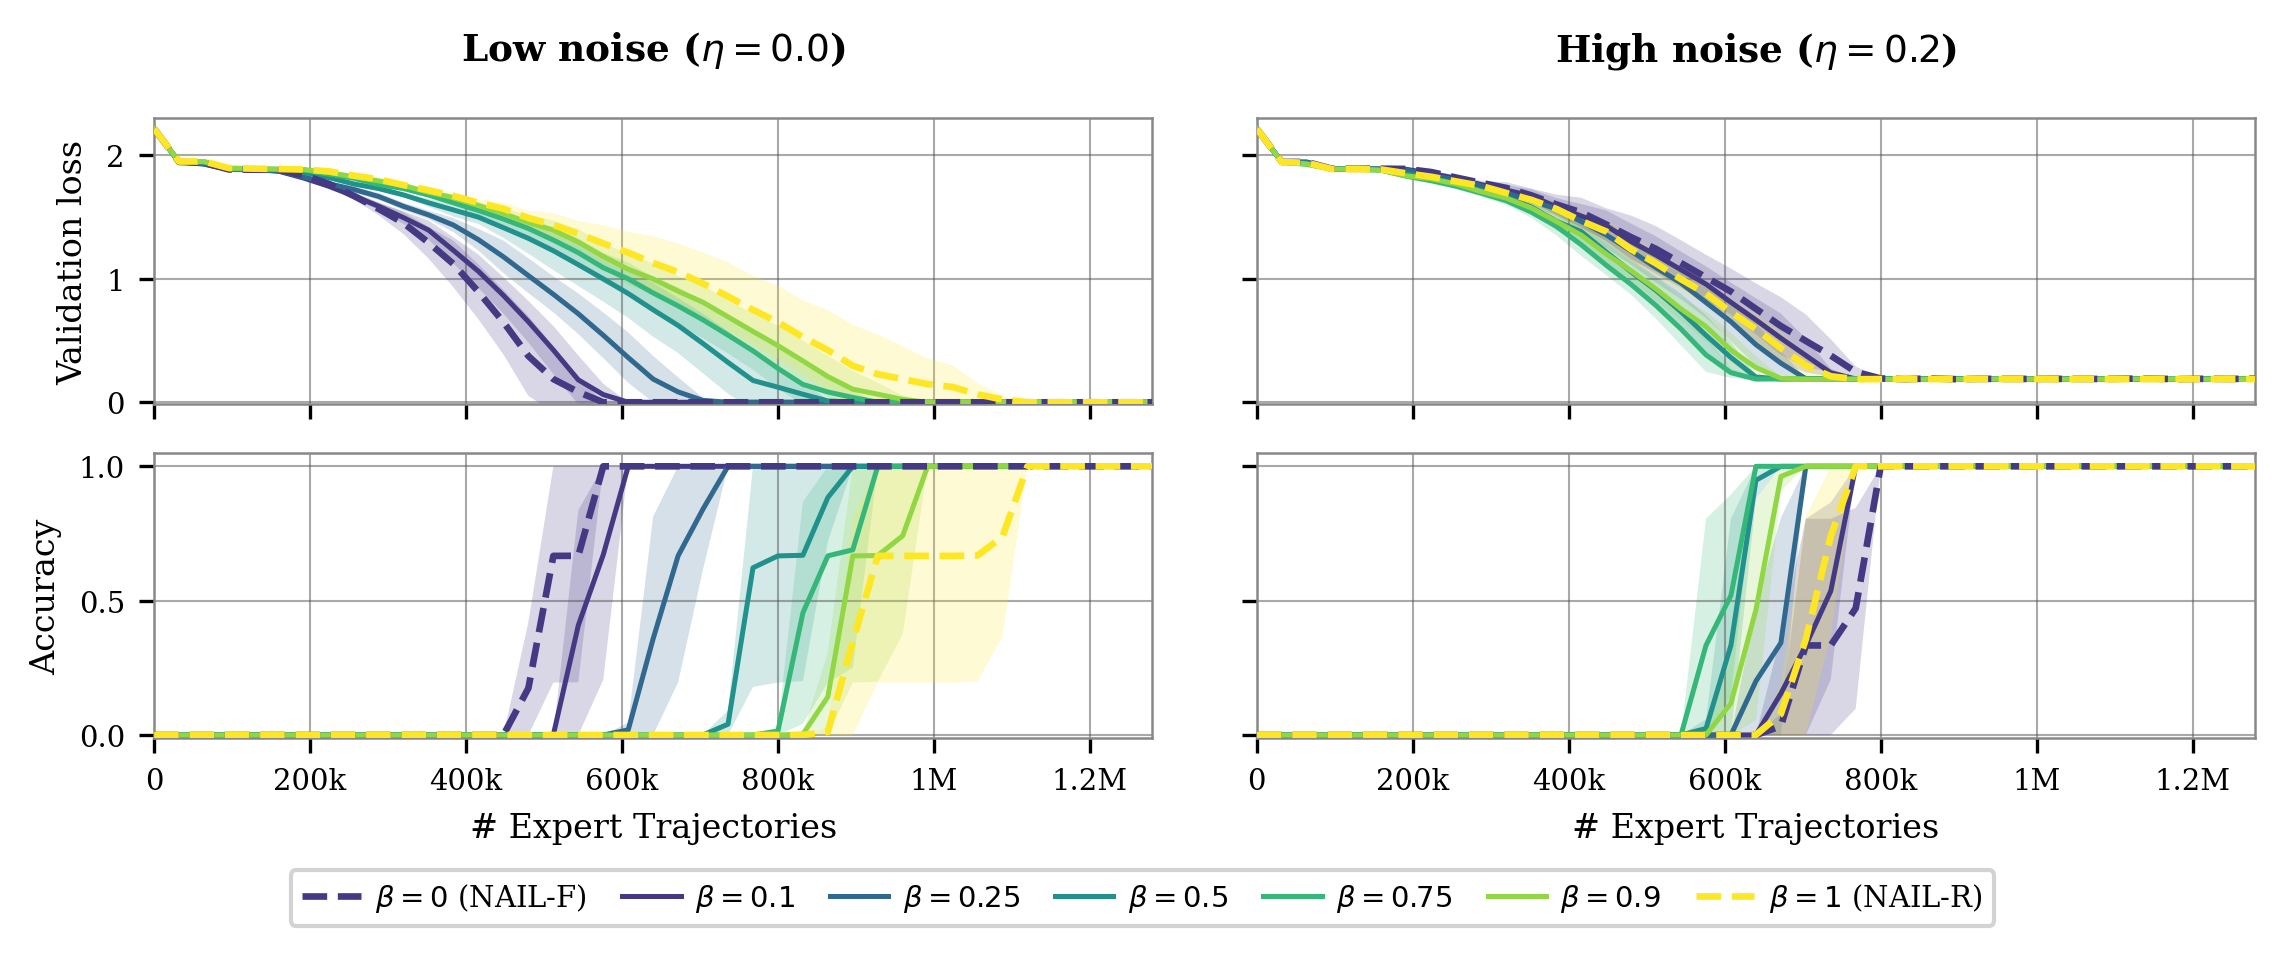

In [74]:
ABLATION_ROOT = Path("/home/peihanliu/NAIL/results/modadd_random_suffix")
ABLATION_SEEDS = [20260417, 20260418, 20260419]
ABLATION_BETAS = [0.1, 0.25, 0.5, 0.75, 0.9]
ABLATION_ETAS = [(0.0, "eta0p0"), (0.2, "eta0p2")]


def beta_str(beta):
    """Format a beta as it appears in the run-dir name (e.g., 0.1 → '0p1')."""
    return f"{beta}".replace(".", "p")


def ablation_run_dir(beta, eta_str, seed):
    return ABLATION_ROOT / f"nail_mixed_beta{beta_str(beta)}_{eta_str}_seed{seed}"


# Loaders for the two y-fields.
load_modadd_loss = partial(load_eval_history, y_fields=("val/loss",))
load_modadd_acc  = partial(load_eval_history, y_fields=("val/clean_full_exact",))


# Color map: viridis sampled at the betas, smaller β → darker/colder.
_cmap = plt.cm.viridis

# Two endpoint anchors: NAIL-F (β=0) and NAIL-R (β=1) — drawn dashed so they
# stand out as reference curves vs the β sweep.
NAIL_F_LABEL = r"$\beta=0$ (NAIL-F)"
NAIL_R_LABEL = r"$\beta=1$ (NAIL-R)"
ANCHOR_LS = "--"
ANCHOR_LW = 1.6   # was 2.8 — thinner for textwidth-sized figure
BETA_LS = "-"
BETA_LW = 1.2     # was 2.0

BETA_COLORS = {b: _cmap((i+1) / (len(ABLATION_BETAS)+2 - 1)) for i, b in enumerate(ABLATION_BETAS)}

ABLATION_ANCHORS = [
    # (legend_label, dir_under_results, color, sort_key)
    (NAIL_F_LABEL, "nail_forward", _cmap((1) / (len(ABLATION_BETAS)+2 - 1)), 0.0),
    (NAIL_R_LABEL, "nail_reverse", _cmap((1+len(ABLATION_BETAS)) / (len(ABLATION_BETAS)+2 - 1)), 1.0),
]


def plot_modadd_beta_ablation(
    save_fig_path: str = None,
    xmul: int = 64,
    figsize: tuple = (5.5, 2.8),                  # ≈ NeurIPS \textwidth
    legend_bbox_to_anchor: tuple = (0.5, -0.04),  # tighter to bottom row
    loss_ylim: tuple = (-0.012, 2.3),
    acc_ylim: tuple = (-0.012, 1.05),
    xlim: tuple = None,        # (lo, hi) applied to every panel; None = auto
    wspace: float = 0.08,
    hspace: float = 0.12,
    ci_alpha: float = 0.20,
):
    """2×2 plot. Top row = val/loss; bottom row = val/clean_full_exact (accuracy).
    Columns: low / high noise. One line per β plus NAIL-F/NAIL-R anchors."""
    # Font sizes tuned for ~5.5" wide figure.
    TITLE_FONTSIZE  = 9
    LABEL_FONTSIZE  = 8
    TICK_FONTSIZE   = 7
    LEGEND_FONTSIZE = 7

    eta_panels = [
        ("Low noise ($\\eta=0.0$)", "eta0p0"),
        ("High noise ($\\eta=0.2$)", "eta0p2"),
    ]

    fig, axes = plt.subplots(
        2, 2,
        figsize=figsize,
        sharey="row",
        sharex="col",
        layout="constrained",
        gridspec_kw={"wspace": wspace, "hspace": hspace},
    )

    def _entries_for_eta(eta_str):
        # Each entry is (label, color, sort_key, seed_to_run, ls, lw, is_anchor).
        out = []
        for label, dir_name, color, key in ABLATION_ANCHORS:
            seed_to_run = {
                s: str(MODADD_ROOT / dir_name / f"{eta_str}_seed{s}")
                for s in MODADD_SEEDS
            }
            out.append((label, color, key, seed_to_run, ANCHOR_LS, ANCHOR_LW, True))
        for beta in ABLATION_BETAS:
            seed_to_run = {s: str(ablation_run_dir(beta, eta_str, s)) for s in ABLATION_SEEDS}
            out.append((fr"$\beta={beta:g}$", BETA_COLORS[beta], float(beta),
                        seed_to_run, BETA_LS, BETA_LW, False))
        out.sort(key=lambda e: e[2])
        return out

    seen_handles = {}  # label -> Line2D, deduped across panels

    for c, (title, eta_str) in enumerate(eta_panels):
        entries = _entries_for_eta(eta_str)
        for r, mode in enumerate(("loss", "acc")):
            ax = axes[r, c]
            for spine in ax.spines.values():
                spine.set_linewidth(0.6); spine.set_color("#888")

            loader = load_modadd_loss if mode == "loss" else load_modadd_acc

            for label, color, _key, seed_to_run, ls, lw, is_anchor in entries:
                xs, mean, std = aggregate_seeds(seed_to_run, loader=loader)
                if xs is None:
                    continue
                xs = np.asarray(xs, dtype=float) * xmul
                mean = np.asarray(mean, dtype=float)
                std = np.asarray(std, dtype=float)

                if mode == "acc":
                    lb = np.clip(mean - std, 0.0, 1.0)
                    ub = np.clip(mean + std, 0.0, 1.0)
                else:
                    lb = mean - std
                    ub = mean + std
                
                ax.plot(xs, mean, color=color, lw=lw, ls=ls,
                        zorder=4 if is_anchor else 3)
                ax.fill_between(xs, lb, ub, facecolor=color, alpha=ci_alpha,
                                edgecolor="none", linewidth=0.0,
                                zorder=2 if is_anchor else 1)

                if label not in seen_handles:
                    seen_handles[label] = Line2D([0], [0], color=color,
                                                 ls=ls, lw=lw, label=label)

            # Per-panel cosmetics.
            if r == 0:
                ax.set_title(title, fontweight="bold", fontsize=TITLE_FONTSIZE)
                ax.set_ylim(*loss_ylim)
                if c == 0:
                    ax.set_ylabel("Validation loss", fontsize=LABEL_FONTSIZE)
                ax.tick_params(axis="x", labelbottom=False)
            else:
                ax.set_ylim(*acc_ylim)
                ax.yaxis.set_major_locator(FixedLocator([0.0, 0.5, 1.0]))
                ax.yaxis.set_major_formatter(FormatStrFormatter("%.1f"))
                ax.set_xlabel("# Expert Trajectories", fontsize=LABEL_FONTSIZE)
                if c == 0:
                    ax.set_ylabel("Accuracy", fontsize=LABEL_FONTSIZE)

            if xlim is not None:
                ax.set_xlim(*xlim)
            ax.tick_params(axis="both", labelsize=TICK_FONTSIZE)
            if c == 1:
                ax.tick_params(axis="y", labelleft=False)
            ax.xaxis.set_major_formatter(FuncFormatter(km_formatter))

    # Two-row legend (5 cols), column-major fill.
    #   Row 0: β=0.1, β=0.25, β=0.5, β=0.75, β=0.9
    #   Row 1: —, NAIL-F (β=0), —, NAIL-R (β=1), —
    empty = Line2D([0], [0], color="none", lw=0, label="")
    n = len(ABLATION_BETAS)  # 5
    nail_f = seen_handles.get(NAIL_F_LABEL, empty)
    nail_r = seen_handles.get(NAIL_R_LABEL, empty)
    row0 = [seen_handles.get(fr"$\beta={b:g}$", empty) for b in ABLATION_BETAS]
    row1 = [empty, nail_f, empty, nail_r, empty]
    interleaved = [h for pair in zip(row0, row1) for h in pair]
    ordered_labels = [
        NAIL_F_LABEL,
        *[fr"$\beta={b:g}$" for b in ABLATION_BETAS],
        NAIL_R_LABEL,
    ]
    handles = [seen_handles[lbl] for lbl in ordered_labels if lbl in seen_handles]

    fig.legend(
        handles=handles, loc="lower center", ncol=len(handles),
        frameon=True, framealpha=0.85, fontsize=LEGEND_FONTSIZE,
        handlelength=2.0, handletextpad=0.5, columnspacing=1.2,
        borderpad=0.4, bbox_to_anchor=legend_bbox_to_anchor,
    )

    if save_fig_path:
        plt.savefig(save_fig_path, bbox_inches="tight")
        print(f"Saved: {save_fig_path}")
    plt.show()


# Match the 1×4 panel plot's modadd cutoff: x ∈ [0, 20000 × 64] = [0, 1.28M].
plot_modadd_beta_ablation(xlim=(0, 20000 * 64),legend_bbox_to_anchor=(0.5, -0.1), figsize=(7.5, 2.8), hspace=0.08, save_fig_path="fig_modadd_mixedkl.pdf")


## Ablation: ModAdd rollout-temperature sweep

Sweeps the student rollout temperature $t \in \{0.1, 0.3, 0.5\}$ for **NAIL-F** and **NAIL-R** separately on ModAdd at low noise ($\eta=0.0$) and high noise ($\eta=0.2$). 2×2 layout mirrors the $\beta$-ablation figure: top row = `val/loss`, bottom row = `val/clean_full_exact`; columns = low / high noise. Each method has its own color family (Blues for NAIL-F, Reds for NAIL-R), darkening with temperature.

Data: `/home/peihanliu/NAIL/results/rollout_temp_ablation/{nail_forward,nail_reverse}/t{temp}_eta{η}_seed{s}/eval_history.jsonl`.


Saved: fig_modadd_temp.pdf


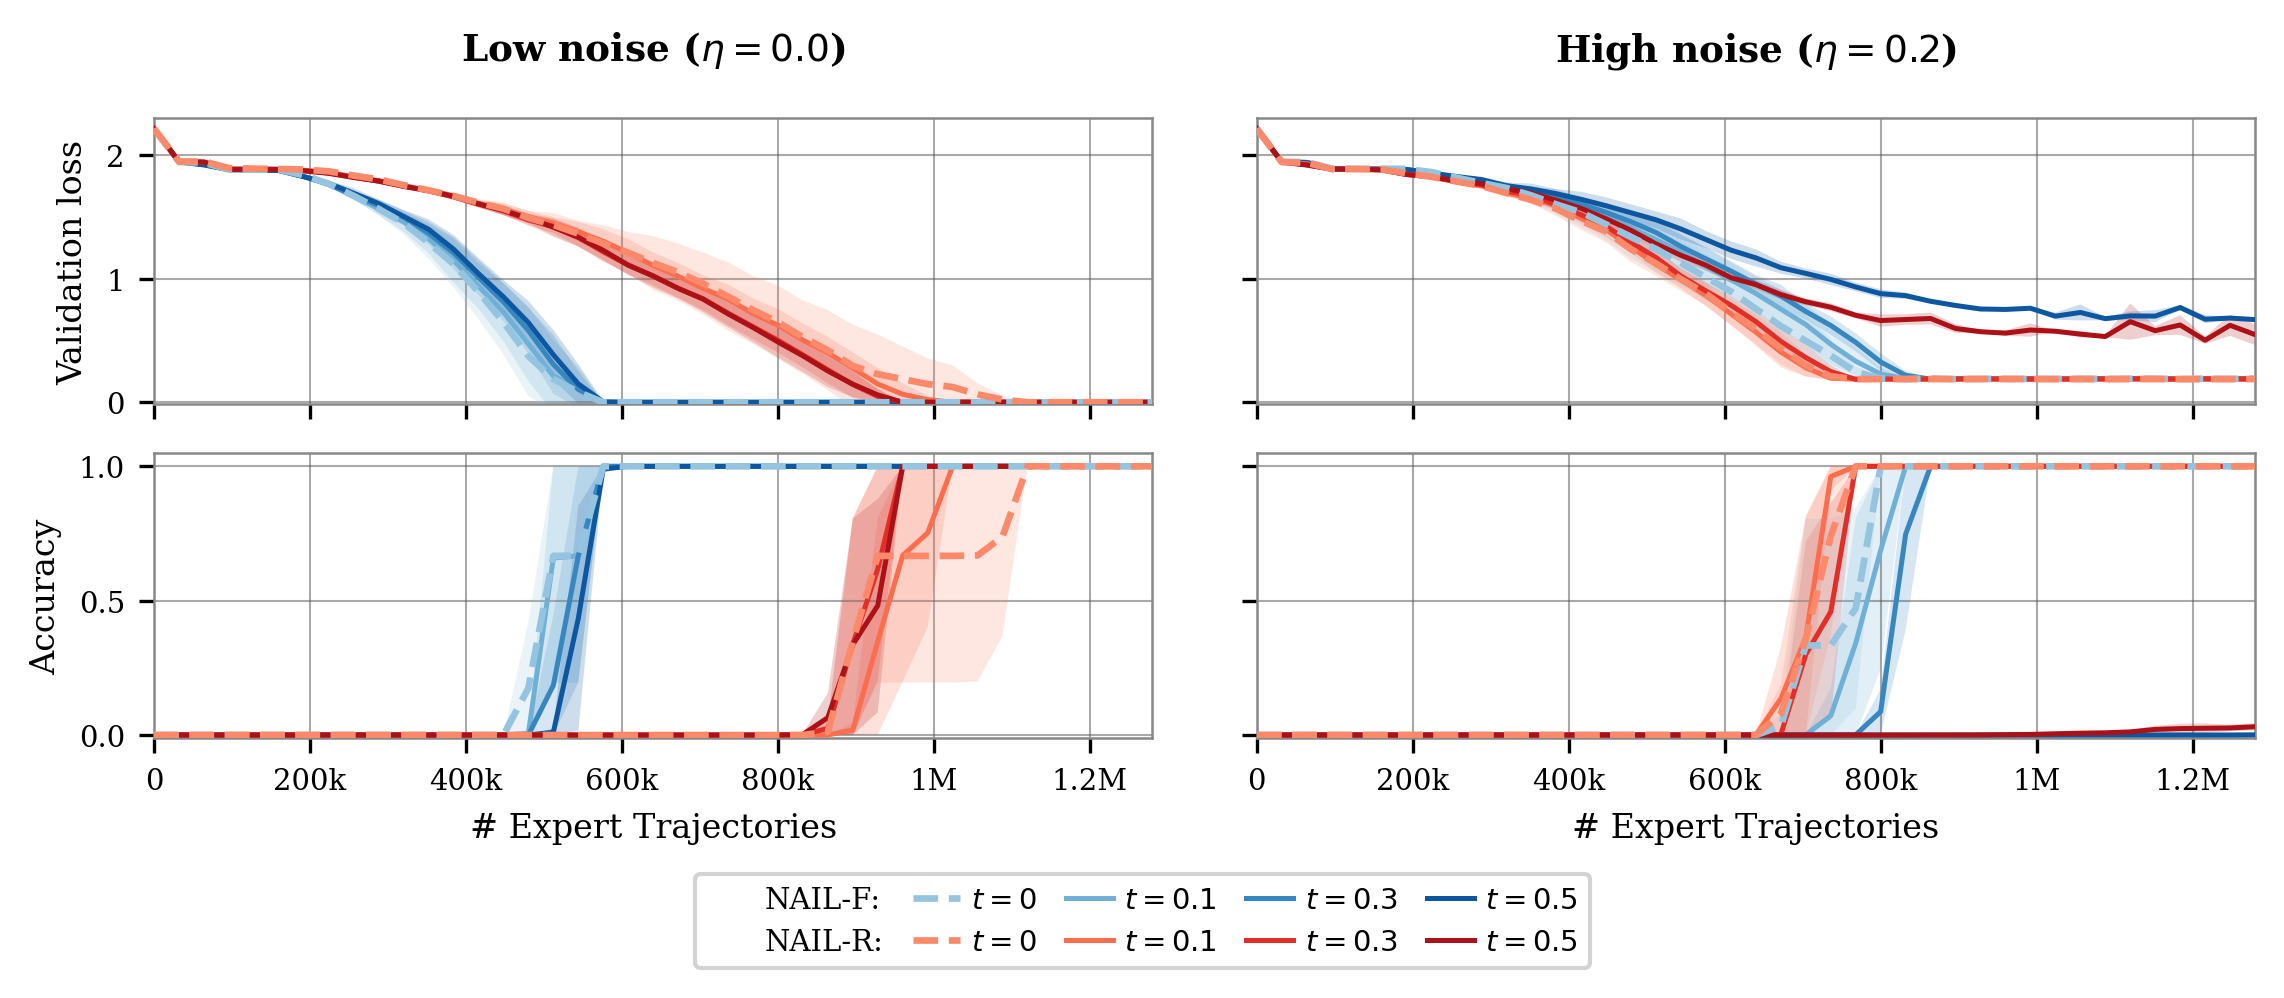

In [75]:
TEMP_ABLATION_ROOT = Path("/home/peihanliu/NAIL/results/rollout_temp_ablation")
TEMP_ABLATION_SEEDS = [20260417, 20260418, 20260419]

# Temperatures to show in the legend (in display order). For t=0 we reuse the
# main NAIL-F / NAIL-R runs (greedy student rollouts == temperature 0). Other
# temperatures load from rollout_temp_ablation/. Slots without data render as
# empty entries so columns align across the two legend rows.
TEMP_ABLATION_TEMPS = [0.0, 0.1, 0.3, 0.5]


def temp_str(temp):
    """Format a temperature as it appears in the run-dir name (e.g., 0.1 -> '0p1')."""
    return f"{temp}".replace(".", "p")


def temp_ablation_run_dir(method_dir, temp, eta_str, seed):
    """Map (method, temp, eta, seed) -> run dir.

    t == 0 means the original greedy NAIL-F / NAIL-R runs in MODADD_ROOT;
    every other temp lives under rollout_temp_ablation/.
    """
    if temp == 0:
        return MODADD_ROOT / method_dir / f"{eta_str}_seed{seed}"
    return TEMP_ABLATION_ROOT / method_dir / f"t{temp_str(temp)}_{eta_str}_seed{seed}"


# (method_label, dir_under_results, colormap)
TEMP_METHODS = [
    ("NAIL-F", "nail_forward", plt.cm.Blues),
    ("NAIL-R", "nail_reverse", plt.cm.Reds),
]
# t=0 (the original NAIL-F/R) is rendered dashed and slightly thicker to act
# as a visual anchor; all other temperatures render solid.
TEMP_ANCHOR_LS = "--"
TEMP_ANCHOR_LW = 1.6
TEMP_LS = "-"
TEMP_LW = 1.2


def _temp_ls_lw(temp):
    if temp == 0:
        return TEMP_ANCHOR_LS, TEMP_ANCHOR_LW
    return TEMP_LS, TEMP_LW


def _temp_color(cmap, temp, all_temps, lo=0.4, hi=0.85):
    """Map temp linearly from [min(all_temps), max(all_temps)] into [lo, hi] of the colormap."""
    sorted_temps = sorted(all_temps)
    if len(sorted_temps) <= 1:
        return cmap(0.5 * (lo + hi))
    frac = (temp - sorted_temps[0]) / (sorted_temps[-1] - sorted_temps[0])
    return cmap(lo + frac * (hi - lo))


from matplotlib.legend_handler import HandlerBase

class _TextOnlyHandler(HandlerBase):
    """Legend handler that draws no visible marker — label only.
    Used for the row-leading "NAIL-F:" / "NAIL-R:" pseudo-entries.
    matplotlib insists on at least one artist per handle, so we return a single
    fully-transparent Rectangle to satisfy the API."""
    def create_artists(self, legend, orig_handle, xdescent, ydescent,
                       width, height, fontsize, trans):
        from matplotlib.patches import Rectangle
        invisible = Rectangle((xdescent, ydescent), 0, 0,
                              fc="none", ec="none", lw=0, alpha=0)
        return [invisible]


def plot_modadd_temp_ablation(
    save_fig_path: str = None,
    xmul: int = 64,
    figsize: tuple = (5.5, 2.8),
    legend_bbox_to_anchor: tuple = (0.5, -0.10),
    loss_ylim: tuple = (-0.012, 2.3),
    acc_ylim: tuple = (-0.012, 1.05),
    xlim: tuple = None,
    wspace: float = 0.08,
    hspace: float = 0.12,
    ci_alpha: float = 0.20,
):
    """2x2 plot. Top row = val/loss; bottom row = val/clean_full_exact (accuracy).
    Columns: low / high noise. One line per (method, temperature).
    Legend: single boxed two-row block, column-major fill so:
        Row 0: NAIL-F:  t=0  t=0.1  t=0.3  t=0.5
        Row 1: NAIL-R:  t=0  t=0.1  t=0.3  t=0.5
    Empty slots stand in for missing (method, temp) combos."""
    TITLE_FONTSIZE  = 9
    LABEL_FONTSIZE  = 8
    TICK_FONTSIZE   = 7
    LEGEND_FONTSIZE = 7

    eta_panels = [
        ("Low noise ($\\eta=0.0$)", "eta0p0"),
        ("High noise ($\\eta=0.2$)", "eta0p2"),
    ]

    fig, axes = plt.subplots(
        2, 2,
        figsize=figsize,
        sharey="row",
        sharex="col",
        layout="constrained",
        gridspec_kw={"wspace": wspace, "hspace": hspace},
    )

    # method_label -> {temp: Line2D handle (label = "$t=...$")}, populated as we plot.
    seen_handles = {ml: {} for ml, *_ in TEMP_METHODS}

    for c, (title, eta_str) in enumerate(eta_panels):
        for r, mode in enumerate(("loss", "acc")):
            ax = axes[r, c]
            for spine in ax.spines.values():
                spine.set_linewidth(0.6); spine.set_color("#888")

            loader = load_modadd_loss if mode == "loss" else load_modadd_acc

            for method_label, dir_name, cmap in TEMP_METHODS:
                for temp in TEMP_ABLATION_TEMPS:
                    seed_to_run = {
                        s: str(temp_ablation_run_dir(dir_name, temp, eta_str, s))
                        for s in TEMP_ABLATION_SEEDS
                    }
                    xs, mean, std = aggregate_seeds(seed_to_run, loader=loader)
                    if xs is None:
                        continue
                    xs = np.asarray(xs, dtype=float) * xmul
                    mean = np.asarray(mean, dtype=float)
                    std = np.asarray(std, dtype=float)

                    if mode == "acc":
                        lb = np.clip(mean - std, 0.0, 1.0)
                        ub = np.clip(mean + std, 0.0, 1.0)
                    else:
                        lb = mean - std
                        ub = mean + std

                    color = _temp_color(cmap, temp, TEMP_ABLATION_TEMPS)
                    ls, lw = _temp_ls_lw(temp)
                    is_anchor = (temp == 0)
                    ax.plot(xs, mean, color=color, lw=lw, ls=ls,
                            zorder=4 if is_anchor else 3)
                    ax.fill_between(xs, lb, ub, facecolor=color, alpha=ci_alpha,
                                    edgecolor="none", linewidth=0.0,
                                    zorder=2 if is_anchor else 1)

                    if temp not in seen_handles[method_label]:
                        seen_handles[method_label][temp] = Line2D(
                            [0], [0], color=color, ls=ls, lw=lw,
                            label=fr"$t={temp:g}$",
                        )

            if r == 0:
                ax.set_title(title, fontweight="bold", fontsize=TITLE_FONTSIZE)
                ax.set_ylim(*loss_ylim)
                if c == 0:
                    ax.set_ylabel("Validation loss", fontsize=LABEL_FONTSIZE)
                ax.tick_params(axis="x", labelbottom=False)
            else:
                ax.set_ylim(*acc_ylim)
                ax.yaxis.set_major_locator(FixedLocator([0.0, 0.5, 1.0]))
                ax.yaxis.set_major_formatter(FormatStrFormatter("%.1f"))
                ax.set_xlabel("# Expert Trajectories", fontsize=LABEL_FONTSIZE)
                if c == 0:
                    ax.set_ylabel("Accuracy", fontsize=LABEL_FONTSIZE)

            if xlim is not None:
                ax.set_xlim(*xlim)
            ax.tick_params(axis="both", labelsize=TICK_FONTSIZE)
            if c == 1:
                ax.tick_params(axis="y", labelleft=False)
            ax.xaxis.set_major_formatter(FuncFormatter(km_formatter))

    # Single legend, 2 rows x (1 + len(TEMPS)) cols, column-major fill.
    #   Col 0: NAIL-F: / NAIL-R:    (text-only, no marker)
    #   Cols 1..N: per-temp entries, F on top row, R on bottom row.
    method_label_F = Line2D([], [], color="none", lw=0, label="NAIL-F:")
    method_label_R = Line2D([], [], color="none", lw=0, label="NAIL-R:")

    def _empty():
        return Line2D([0], [0], color="none", lw=0, label=" ")

    handles_for_legend = [method_label_F, method_label_R]
    for t in TEMP_ABLATION_TEMPS:
        handles_for_legend.append(seen_handles["NAIL-F"].get(t, _empty()))
        handles_for_legend.append(seen_handles["NAIL-R"].get(t, _empty()))

    fig.legend(
        handles=handles_for_legend,
        loc="lower center",
        ncol=1 + len(TEMP_ABLATION_TEMPS),
        bbox_to_anchor=legend_bbox_to_anchor,
        frameon=True, framealpha=0.85, fontsize=LEGEND_FONTSIZE,
        handlelength=1.6, handletextpad=0.4, columnspacing=1.0,
        borderpad=0.4,
        handler_map={
            method_label_F: _TextOnlyHandler(),
            method_label_R: _TextOnlyHandler(),
        },
    )

    if save_fig_path:
        plt.savefig(save_fig_path, bbox_inches="tight")
        print(f"Saved: {save_fig_path}")
    plt.show()


# Match the modadd cutoff used elsewhere: x in [0, 20000 * 64] = [0, 1.28M].
plot_modadd_temp_ablation(
    xlim=(0, 20000 * 64),
    legend_bbox_to_anchor=(0.5, -0.15),
    figsize=(7.5, 2.8),
    hspace=0.08,
    save_fig_path="fig_modadd_temp.pdf",
)


## Ablation: ModAdd JSD-β sweep

Sweeps the JSD interpolation weight $\beta \in \{0.0, 0.1, 0.25, 0.5, 0.75, 0.9, 1.0\}$ for ModAdd at low ($\eta=0.0$) and high ($\eta=0.2$) noise. 2×2 layout mirrors the β-ablation figure: top row = `val/loss`, bottom row = `val/clean_full_exact`; columns = low / high noise. Each line is a JSD β value (mean ± std across 3 seeds), colored by viridis with $\beta=0$ darkest, $\beta=1$ brightest.

Data: `/home/peihanliu/NAIL/results/jsd_ablation/nail_jsd_beta{β}_eta{η}_seed{s}/eval_history.jsonl`.


Saved: fig_modadd_jsd.pdf


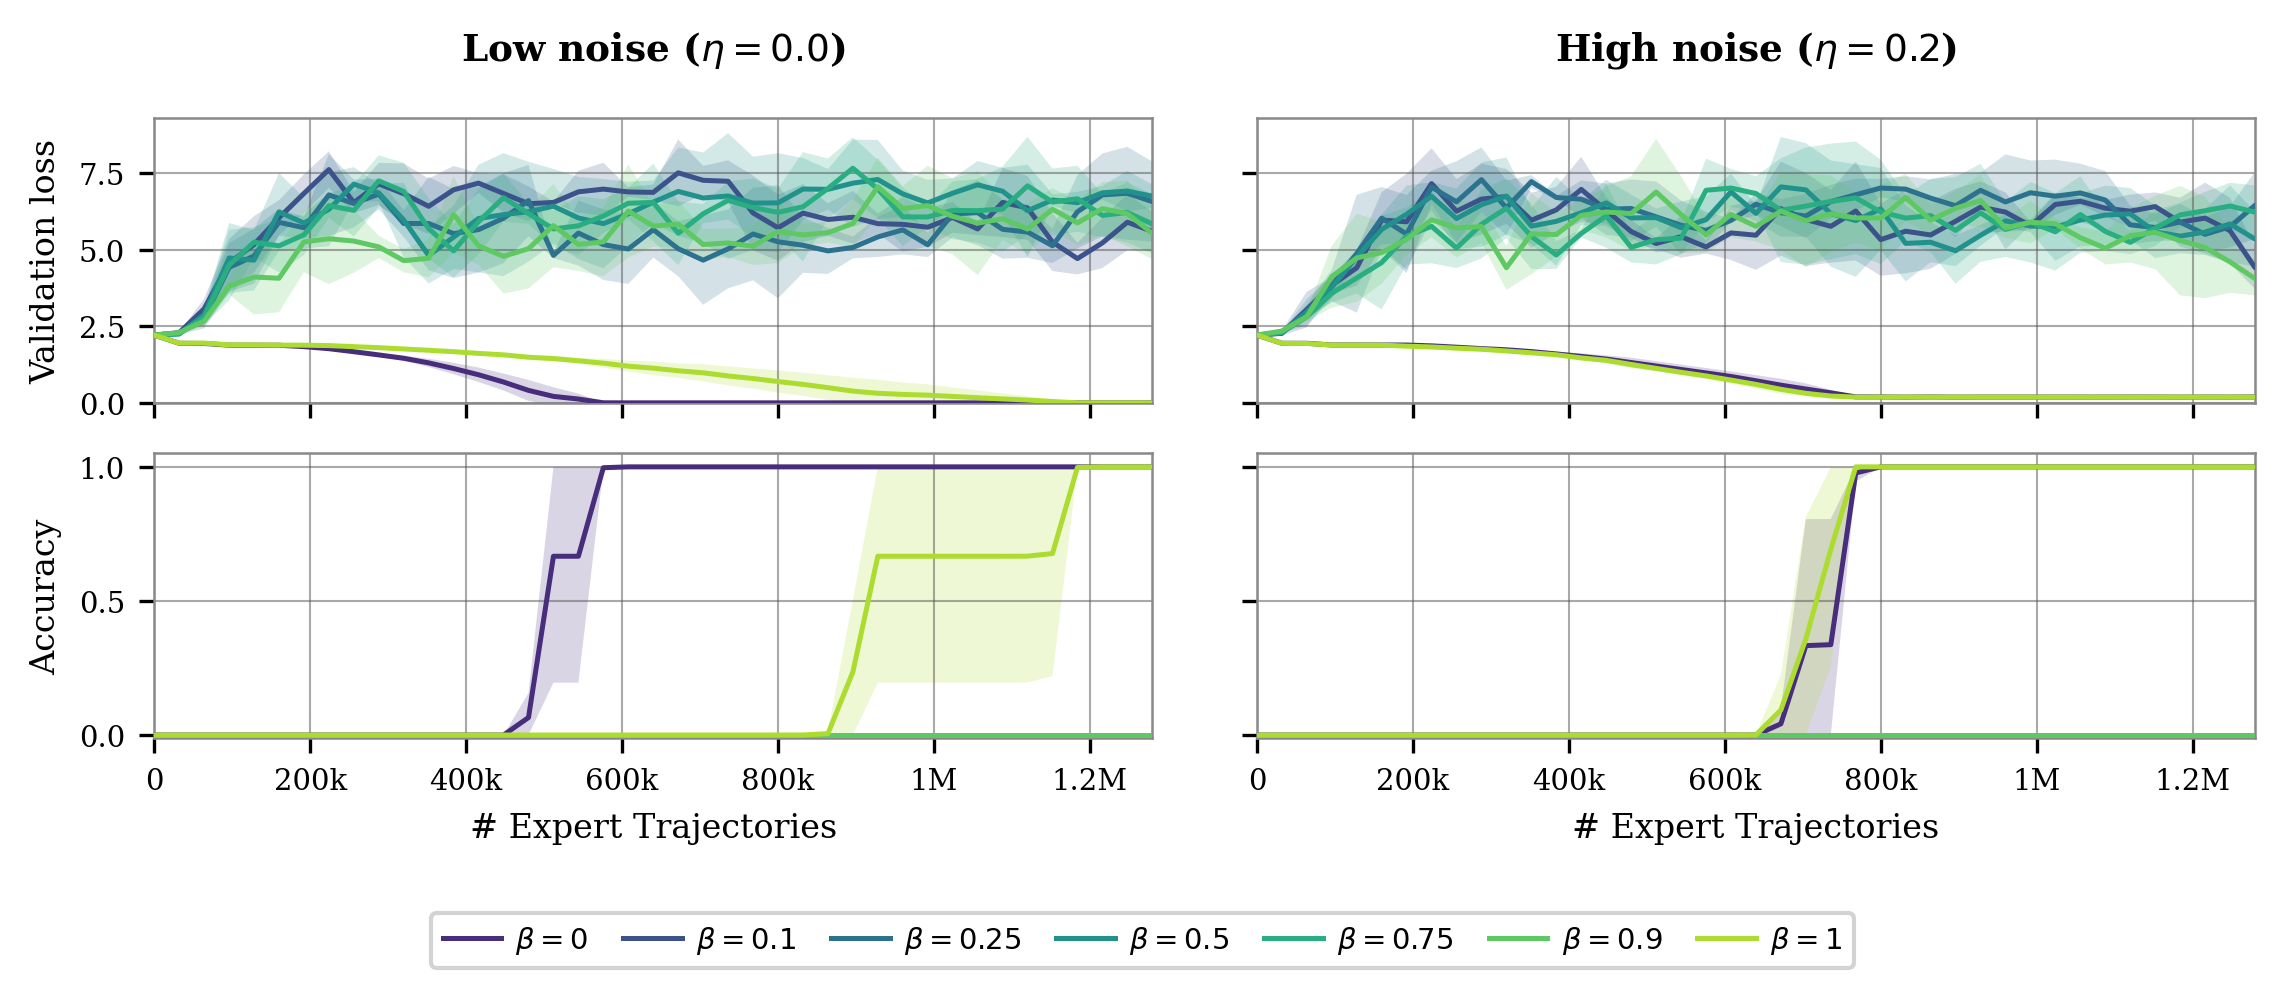

In [79]:
JSD_ABLATION_ROOT = Path("/home/peihanliu/NAIL/results/jsd_ablation")
JSD_ABLATION_SEEDS = [20260417, 20260418, 20260419]
JSD_ABLATION_BETAS = [0.0, 0.1, 0.25, 0.5, 0.75, 0.9, 1.0]


def jsd_beta_str(beta):
    """Format a beta as it appears in the run-dir name (e.g., 0.1 -> '0p1')."""
    return f"{beta}".replace(".", "p")


def jsd_ablation_run_dir(beta, eta_str, seed):
    return JSD_ABLATION_ROOT / f"nail_jsd_beta{jsd_beta_str(beta)}_{eta_str}_seed{seed}"


# Color map sampled across the JSD-β range (β=0 dark, β=1 bright).
_jsd_cmap = plt.cm.viridis
JSD_BETA_COLORS = {
    b: _jsd_cmap((i + 1) / (len(JSD_ABLATION_BETAS) + 1))
    for i, b in enumerate(JSD_ABLATION_BETAS)
}
JSD_BETA_LS = "-"
JSD_BETA_LW = 1.2


def plot_modadd_jsd_beta_ablation(
    save_fig_path: str = None,
    xmul: int = 64,
    figsize: tuple = (5.5, 2.8),
    legend_bbox_to_anchor: tuple = (0.5, -0.10),
    loss_ylim: tuple = (-0.012, 9.3),
    acc_ylim: tuple = (-0.012, 1.05),
    xlim: tuple = None,
    wspace: float = 0.08,
    hspace: float = 0.12,
    ci_alpha: float = 0.20,
):
    """2x2 plot. Top row = val/loss; bottom row = val/clean_full_exact (accuracy).
    Columns: low / high noise. One line per JSD-β."""
    TITLE_FONTSIZE  = 9
    LABEL_FONTSIZE  = 8
    TICK_FONTSIZE   = 7
    LEGEND_FONTSIZE = 7

    eta_panels = [
        ("Low noise ($\\eta=0.0$)", "eta0p0"),
        ("High noise ($\\eta=0.2$)", "eta0p2"),
    ]

    fig, axes = plt.subplots(
        2, 2,
        figsize=figsize,
        sharey="row",
        sharex="col",
        layout="constrained",
        gridspec_kw={"wspace": wspace, "hspace": hspace},
    )

    seen_handles = {}  # beta -> Line2D handle, deduped across panels.

    for c, (title, eta_str) in enumerate(eta_panels):
        for r, mode in enumerate(("loss", "acc")):
            ax = axes[r, c]
            for spine in ax.spines.values():
                spine.set_linewidth(0.6); spine.set_color("#888")

            loader = load_modadd_loss if mode == "loss" else load_modadd_acc

            for beta in JSD_ABLATION_BETAS:
                seed_to_run = {
                    s: str(jsd_ablation_run_dir(beta, eta_str, s))
                    for s in JSD_ABLATION_SEEDS
                }
                xs, mean, std = aggregate_seeds(seed_to_run, loader=loader)
                if xs is None:
                    continue
                xs = np.asarray(xs, dtype=float) * xmul
                mean = np.asarray(mean, dtype=float)
                std = np.asarray(std, dtype=float)

                if mode == "acc":
                    lb = np.clip(mean - std, 0.0, 1.0)
                    ub = np.clip(mean + std, 0.0, 1.0)
                else:
                    lb = mean - std
                    ub = mean + std

                color = JSD_BETA_COLORS[beta]
                ax.plot(xs, mean, color=color, lw=JSD_BETA_LW, ls=JSD_BETA_LS, zorder=3)
                ax.fill_between(xs, lb, ub, facecolor=color, alpha=ci_alpha,
                                edgecolor="none", linewidth=0.0, zorder=1)

                if beta not in seen_handles:
                    seen_handles[beta] = Line2D(
                        [0], [0], color=color, ls=JSD_BETA_LS, lw=JSD_BETA_LW,
                        label=fr"$\beta={beta:g}$",
                    )

            if r == 0:
                ax.set_title(title, fontweight="bold", fontsize=TITLE_FONTSIZE)
                ax.set_ylim(*loss_ylim)
                if c == 0:
                    ax.set_ylabel("Validation loss", fontsize=LABEL_FONTSIZE)
                ax.tick_params(axis="x", labelbottom=False)
            else:
                ax.set_ylim(*acc_ylim)
                ax.yaxis.set_major_locator(FixedLocator([0.0, 0.5, 1.0]))
                ax.yaxis.set_major_formatter(FormatStrFormatter("%.1f"))
                ax.set_xlabel("# Expert Trajectories", fontsize=LABEL_FONTSIZE)
                if c == 0:
                    ax.set_ylabel("Accuracy", fontsize=LABEL_FONTSIZE)

            if xlim is not None:
                ax.set_xlim(*xlim)
            ax.tick_params(axis="both", labelsize=TICK_FONTSIZE)
            if c == 1:
                ax.tick_params(axis="y", labelleft=False)
            ax.xaxis.set_major_formatter(FuncFormatter(km_formatter))

    # Single-row legend, β ascending.
    handles = [seen_handles[b] for b in JSD_ABLATION_BETAS if b in seen_handles]
    fig.legend(
        handles=handles, loc="lower center", ncol=len(handles),
        bbox_to_anchor=legend_bbox_to_anchor,
        frameon=True, framealpha=0.85, fontsize=LEGEND_FONTSIZE,
        handlelength=2.0, handletextpad=0.5, columnspacing=1.2, borderpad=0.4,
    )

    if save_fig_path:
        plt.savefig(save_fig_path, bbox_inches="tight")
        print(f"Saved: {save_fig_path}")
    plt.show()


# Match the modadd cutoff used elsewhere: x in [0, 20000 * 64] = [0, 1.28M].
plot_modadd_jsd_beta_ablation(
    xlim=(0, 20000 * 64),
    legend_bbox_to_anchor=(0.5, -0.15),
    figsize=(7.5, 2.8),
    hspace=0.08,
    save_fig_path="fig_modadd_jsd.pdf",
)
